# Integrated Gas-Solar Hybrid Asset Model — Nigeria
## A Three-Equation SUR System with Correlated Monte Carlo and Project Finance

**Profile:** BSc Geology | MSc Petroleum & Energy Engineering | MSc Financial Engineering | Solar experience

---

## The Analytical Argument

To optimise a gas-solar hybrid energy asset in Nigeria, three quantities must be modelled simultaneously and jointly:

1. **Gas supply price** — what it costs to fuel a gas thermal plant
2. **Gas thermal plant capacity factor** — how much of that plant actually runs
3. **Solar PV capacity factor** — how much the solar component generates

These are not independent. They share structural drivers: FX crises raise O&M costs for both technologies. Grid instability curtails both simultaneously, if solar connects to the National grid. Sector liquidity failures reduce offtake for both. When NLNG utilisation rises, domestic gas supply tightens and power output falls (Nigerias Domestic Gas Obligation Regulation tries to solve this) — while solar is unaffected but faces the same grid evacuation bottleneck.

Modelling them independently ignores this cross-equation error correlation. This notebook estimates all three equations jointly as a **Seemingly Unrelated Regression (SUR/FGLS)** system, simulates them jointly under a correlated stochastic framework, and feeds the joint outputs into a project finance waterfall to find the Sharpe-optimal gas-solar allocation and hedge ratio.

---

## Full Notebook Flow

```
PART 1 — FOUNDATIONS
  Cell 0:  Imports and configuration
  Cell 1:  Data assembly and variable catalogue (30+ variables, 8 categories)
  Cell 2:  Stationarity testing (ADF — every variable)
  Cell 3:  Cointegration testing (Engle-Granger — Equation 1)

PART 2 — THE THREE-EQUATION REGRESSION SYSTEM
  Cell 4:  Equation 1 — Gas price (OLS + NW-HAC SE)
  Cell 5:  Full regressor universe for Eq 2 and Eq 3
  Cell 6:  Multicollinearity audit (VIF — documenting the problem)
  Cell 7:  PCA factor reduction (solving multicollinearity — 20+ → orthogonal factors)
  Cell 8:  Equation 2 — Gas thermal CF (OLS on PCA factors + NW-HAC)
  Cell 9:  Equation 3 — Solar CF (OLS on PCA factors + NW-HAC)
  Cell 10: Cross-equation residual correlation test (SUR motivation)
  Cell 11: SUR estimation via FGLS (joint efficiency gain documented)

PART 3 — CORRELATED MONTE CARLO ENGINE
  Cell 12: Market driver covariance and Cholesky decomposition
  Cell 13: Joint path simulation (gas price, gas CF, solar CF from same factors)

PART 4 — PROJECT FINANCE
  Cell 14: Stochastic dispatch and project finance waterfall
  Cell 15: Risk metrics (P10/P50/P90, VaR, CVaR, DSCR)

PART 5 — PORTFOLIO AND HEDGE OPTIMISATION
  Cell 16: Sharpe-optimal gas-solar allocation
  Cell 17: Periodic hedge ratio optimisation

PART 6 — REAL DATA INTEGRATION
  Cell 18: Data pipeline (runnable with graceful fallback)
```

---

## Colour coding
- `# ── PLACEHOLDER ──` = synthetic data; real source documented
- `# ── SUR ──` = new jointly-estimated section
- `# ── FIX ──` = corrected from v1


---
# PART 1 — FOUNDATIONS
## Cell 0 — Imports and Configuration

In [1]:
# ══════════════════════════════════════════════════════════════════════
# CELL 0 — IMPORTS
# pip install pandas numpy matplotlib scipy scikit-learn
# ══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import minimize
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F9F9F9',
    'axes.grid':True,'grid.alpha':0.25,
    'axes.spines.top':False,'axes.spines.right':False,'font.size':10
})

START_DATE = '2015-01-01';  END_DATE  = '2025-12-31'
N_SIMS     = 5000;          N_MONTHS  = 120
RANDOM_SEED= 42;            np.random.seed(RANDOM_SEED)

print(f'Config: {N_SIMS:,} sims × {N_MONTHS} months | seed={RANDOM_SEED}')

Config: 5,000 sims × 120 months | seed=42


---
## Cell 1 — Data Assembly and Variable Catalogue

Every variable has a documented source. Synthetic series are flagged `# ── PLACEHOLDER ──` and will be updated as data becomes available.

### Variable catalogue by equation

**Equation 1 — Gas price drivers:**
`ln(brent)`, `ln(usdngn)`, `ln(demand_mw)`, `ttf_jkm`, `nlng_util`

**Equation 2 — Gas thermal CF drivers (8 categories, 20 variables):**

| Category | Variables |
|---|---|
| Gas supply | gas_to_power, domestic_alloc, gas_price (from Eq1), nlng_util, ttf_jkm |
| FX crisis | ln_usdngn, fx_reserves, inflation, receivables |
| LNG exports | jkm_netback |
| Pipeline vandalism | pipeline_down, vandalism_idx, fm_dummy |
| Maintenance | forced_outage, plant_age_gas, eaf |
| Policy | grid_demand_norm, dgso_dummy |
| Transmission | wheeling_cap, freq_collapse, tcn_curtailment |
| Sector liquidity | nbet_pay_ratio, disco_collect, market_shortfall |

**Equation 3 — Solar CF drivers (6 categories, 13 variables):**

| Category | Variables |
|---|---|
| Irradiance | ghi, dni |
| Temperature/season | temp_c, harmattan, precip_mm, aerosol_od |
| Grid evacuation | tcn_curtailment*, freq_collapse*, grid_voltage_dev |
| FX | ln_usdngn* |
| Sector liquidity | nbet_pay_ratio*, disco_collect* |
| Degradation | solar_plant_age |

*Shared with Equation 2 — creates cross-equation error correlation → SUR advantageous


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1
# Load reconstructed master panel
# No synthetic fallback required
# ═══════════════════════════════════════════════════════════════════════

import os
# Safety
_RANDOM_SEED = globals().get('RANDOM_SEED', 42)
_START_DATE  = globals().get('START_DATE', '2015-01-01')
_END_DATE    = globals().get('END_DATE', '2026-05-01')

RANDOM_SEED = _RANDOM_SEED
START_DATE  = _START_DATE
END_DATE    = _END_DATE

np.random.seed(RANDOM_SEED)

dates = pd.date_range(
    START_DATE,
    END_DATE,
    freq='MS'
)

# ──────────────────────────────────────────────────────────────
# LOAD RECONSTRUCTED PANEL
# ──────────────────────────────────────────────────────────────

PANEL_PATH = "master_panel_reconstructed_v2.csv"

if not os.path.exists(PANEL_PATH):
    raise FileNotFoundError(
        f"{PANEL_PATH} not found. "
        "Run reconstruction engine first."
    )

df = pd.read_csv(
    PANEL_PATH,
    index_col=0,
    parse_dates=True
)

df = df.reindex(dates).ffill().bfill()

# ──────────────────────────────────────────────────────────────
# VARIABLE ALIASES FOR BACKWARD COMPATIBILITY
# ──────────────────────────────────────────────────────────────

if "eaf" not in df.columns and "PAF" in df.columns:
    df["eaf"] = df["PAF"]

if "nbet_pay_ratio" not in df.columns and "nbet_mo_pay_ratio" in df.columns:
    df["nbet_pay_ratio"] = df["nbet_mo_pay_ratio"]

if "disco_collect" not in df.columns and "disco_collect_efficiency" in df.columns:
    df["disco_collect"] = df["disco_collect_efficiency"]


# ──────────────────────────────────────────────────────────────
# CANONICAL VARIABLE NAMES
# ──────────────────────────────────────────────────────────────

rename_map = {}

if "nbet_pay_ratio" in df.columns:
    rename_map["nbet_pay_ratio"] = "nbet_ratio"

if "Total_E_Rec_by_disco" in df.columns:
    rename_map["Total_E_Rec_by_disco"] = "receivables"

df = df.rename(columns=rename_map)

# Create standalone variables expected by old notebook cells

for col in df.columns:
    globals()[col] = df[col].values

In [3]:
df.columns

Index(['brent', 'usdngn', 'ttf_jkm', 'jkm_netback', 'ghi', 'dni', 'temp_c',
       'precip_mm', 'aerosol_od', 'fx_reserves', 'inflation', 'gas_price',
       'harmattan', 'fm_dummy', 'pipeline_down', 'vandalism_idx',
       'plant_age_gas', 'gas_to_power', 'domestic_alloc', 'eaf',
       'Transmission_Loss_factor', 'freq_collapse', 'load_variance', 'ATC&C',
       'Tech_&_commercial_loss', 'collection_loss', 'receivables',
       'Total_E_Billed_by_Disco', 'Total_E_paid_to_Disco', 'market_shortfall',
       'disco_collect', 'Billing_efficiency', 'nbet_ratio', 'gas_cf',
       'solar_cf', 'Gas_constraint', 'Distribution_constraint',
       'Transmission_constraint'],
      dtype='str')

In [4]:
for v in [
    "Gas_constraint",
    "Transmission_constraint",
    "Distribution_constraint"
]:
    print(v)
    print(df[v].describe())

Gas_constraint
count    1.320000e+02
mean     1.127652e+06
std      8.902601e+05
min      0.000000e+00
25%      4.298178e+05
50%      1.329475e+06
75%      1.452000e+06
max      4.739451e+06
Name: Gas_constraint, dtype: float64
Transmission_constraint
count       132.000000
mean      59599.677159
std       30646.480971
min           0.000000
25%       37200.000000
50%       59683.893800
75%       74344.913953
max      148800.000000
Name: Transmission_constraint, dtype: float64
Distribution_constraint
count    1.320000e+02
mean     6.377935e+06
std      1.578868e+07
min      0.000000e+00
25%      7.440000e+04
50%      9.949421e+05
75%      2.326204e+06
max      5.913875e+07
Name: Distribution_constraint, dtype: float64


Variables found:
['gas_price', 'gas_cf', 'solar_cf', 'brent', 'usdngn', 'ttf_jkm', 'jkm_netback', 'inflation', 'fx_reserves', 'gas_to_power', 'domestic_alloc', 'eaf', 'pipeline_down', 'Gas_constraint', 'Transmission_constraint', 'Distribution_constraint', 'market_shortfall', 'ATC&C', 'nbet_ratio', 'freq_collapse', 'ghi', 'dni', 'temp_c', 'precip_mm', 'aerosol_od', 'harmattan']

gas_price
count    132.000000
mean       1.946061
std        0.189824
min        1.750000
25%        1.750000
50%        2.050000
75%        2.100000
max        2.180000
Name: gas_price, dtype: float64
Skewness: 0.02
Kurtosis: -1.86


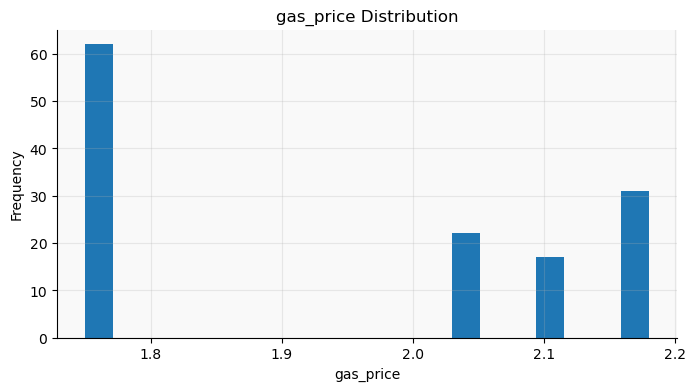

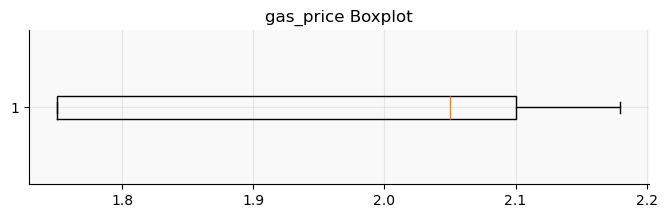


gas_cf
count    132.000000
mean      27.405734
std        3.270559
min       22.810000
25%       24.980000
50%       27.500000
75%       29.682500
max       34.660000
Name: gas_cf, dtype: float64
Skewness: 0.18
Kurtosis: -0.66


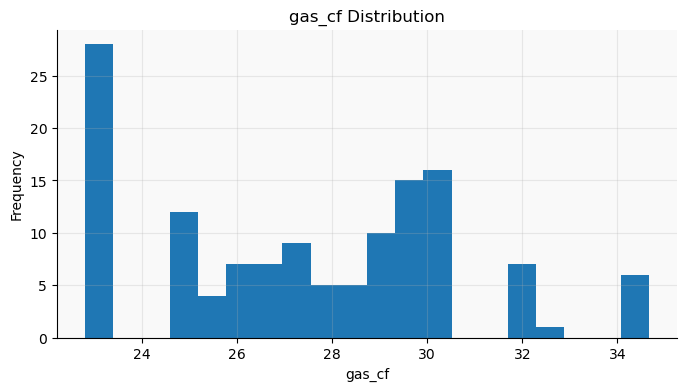

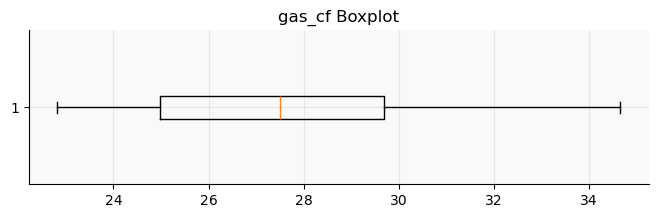


solar_cf
count    132.000000
mean      16.761364
std        3.241234
min       12.500000
25%       13.500000
50%       16.250000
75%       19.000000
max       23.000000
Name: solar_cf, dtype: float64
Skewness: 0.37
Kurtosis: -1.14


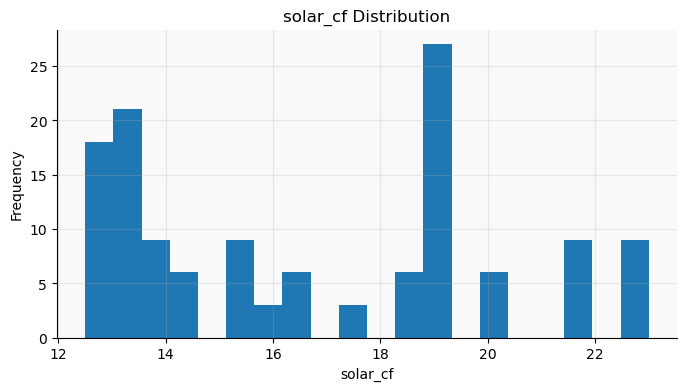

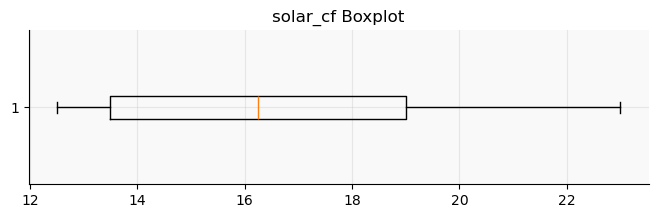


brent
count    132.000000
mean      67.701431
std       16.830220
min       29.854346
25%       54.576667
50%       65.363750
75%       78.548511
max      117.909900
Name: brent, dtype: float64
Skewness: 0.54
Kurtosis: 0.65


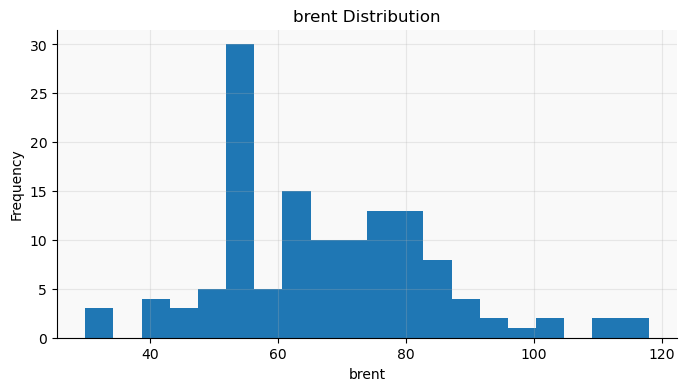

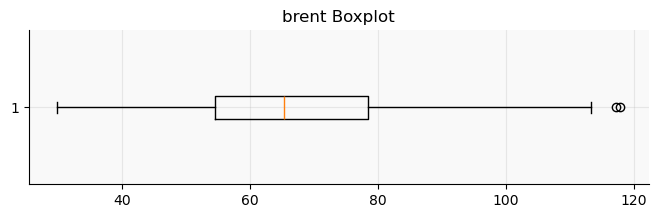


usdngn
count     132.000000
mean      615.586803
std       462.434023
min       305.000000
25%       305.000000
50%       369.000000
75%       683.750000
max      1601.481968
Name: usdngn, dtype: float64
Skewness: 1.27
Kurtosis: -0.14


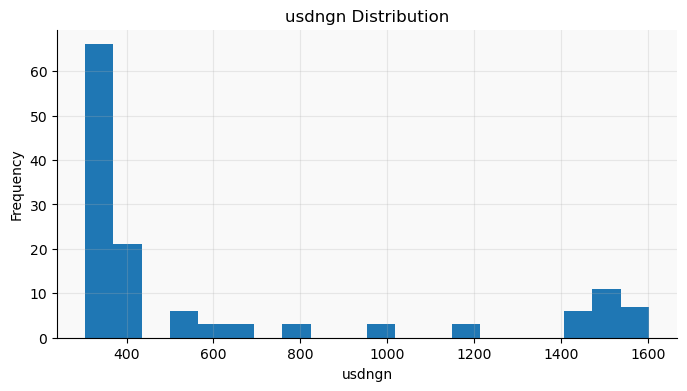

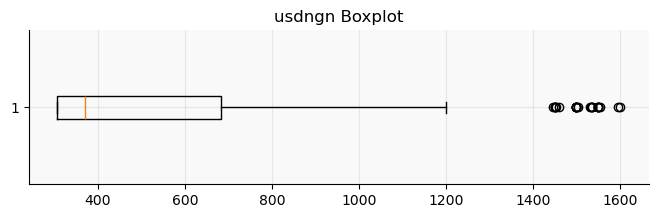


ttf_jkm
count    132.000000
mean      11.351320
std       10.604843
min        1.769762
25%        6.144349
50%        7.204580
75%       11.693664
max       56.304489
Name: ttf_jkm, dtype: float64
Skewness: 2.45
Kurtosis: 6.10


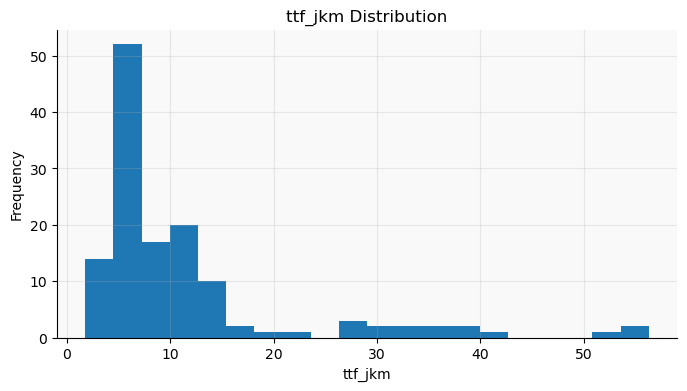

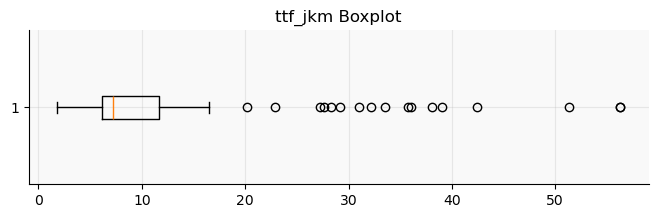


jkm_netback
count    132.000000
mean      11.139054
std        3.334388
min        6.211493
25%        8.269091
50%       10.258489
75%       12.625065
max       21.614642
Name: jkm_netback, dtype: float64
Skewness: 1.25
Kurtosis: 1.53


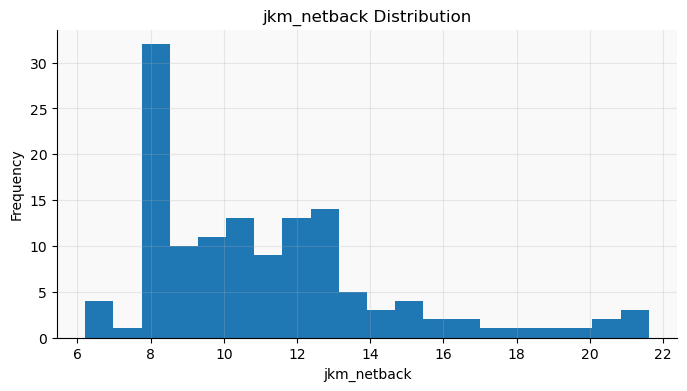

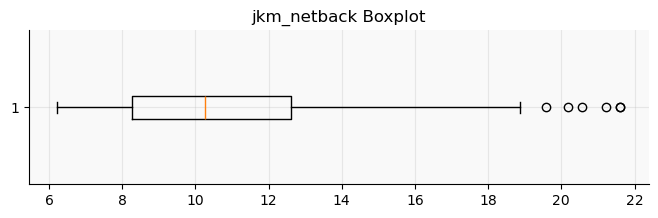


inflation
count    132.000000
mean      18.684828
std        6.772261
min       11.270000
25%       14.505000
50%       16.400000
75%       20.482500
max       33.242097
Name: inflation, dtype: float64
Skewness: 1.16
Kurtosis: 0.18


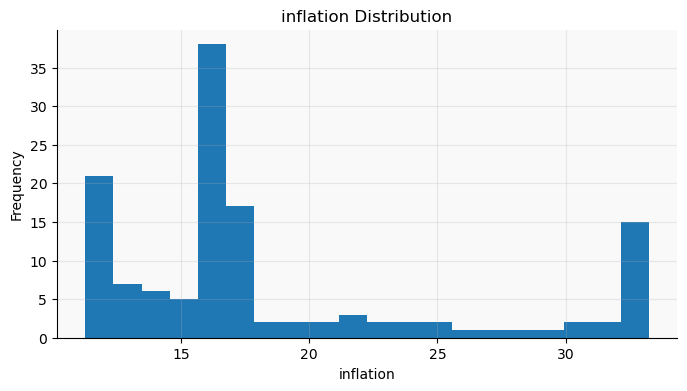

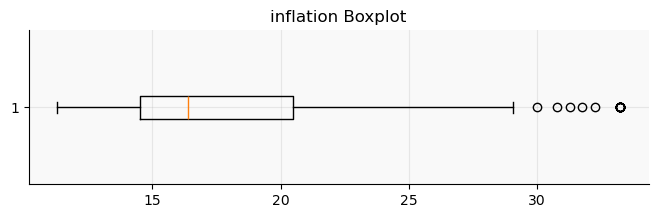


fx_reserves
count    132.000000
mean      36.159462
std        5.578916
min       28.174227
25%       32.431807
50%       36.031455
75%       39.907351
max       47.788529
Name: fx_reserves, dtype: float64
Skewness: 0.13
Kurtosis: -0.87


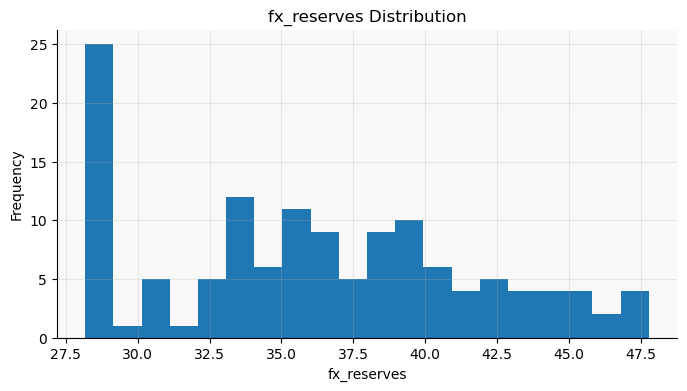

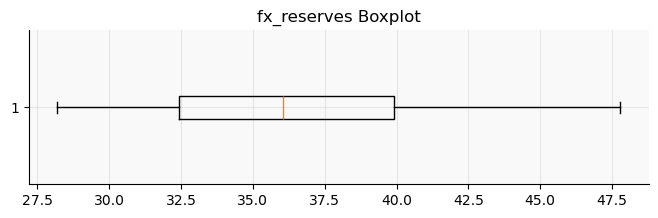


gas_to_power
count      132.000000
mean     27146.739551
std        569.652474
min      23782.360000
25%      26973.877270
50%      27313.288890
75%      27494.997150
max      27722.197480
Name: gas_to_power, dtype: float64
Skewness: -3.17
Kurtosis: 13.96


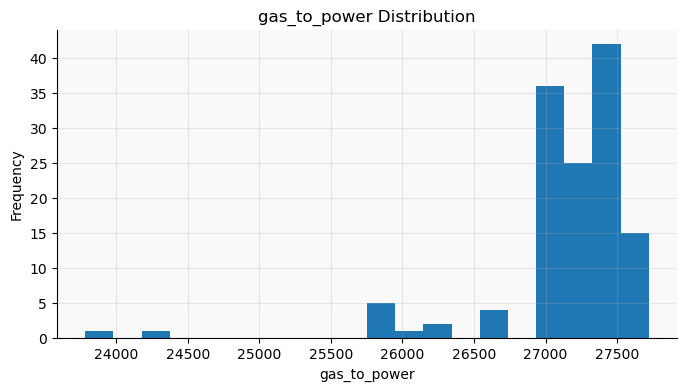

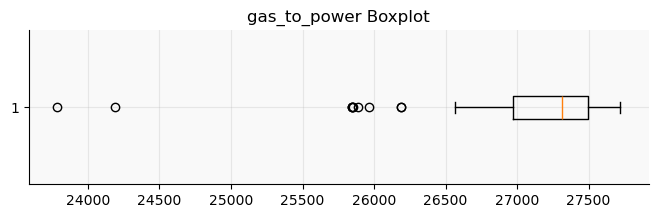


domestic_alloc
count      132.000000
mean     30129.722544
std      19005.833733
min          0.000000
25%      21331.292708
50%      32099.912465
75%      39105.697790
max      84421.043310
Name: domestic_alloc, dtype: float64
Skewness: 0.43
Kurtosis: 0.60


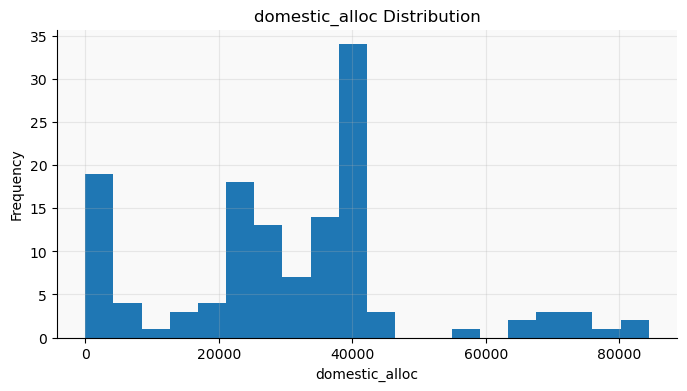

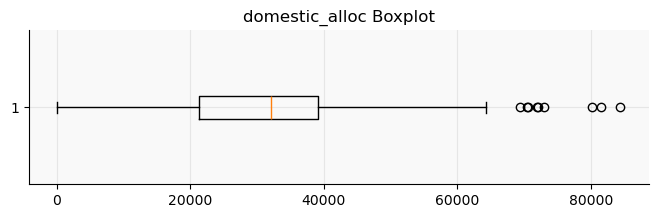


eaf
count    132.000000
mean      45.818217
std       13.016966
min       27.490000
25%       33.280000
50%       43.050000
75%       61.645713
max       64.700000
Name: eaf, dtype: float64
Skewness: 0.39
Kurtosis: -1.41


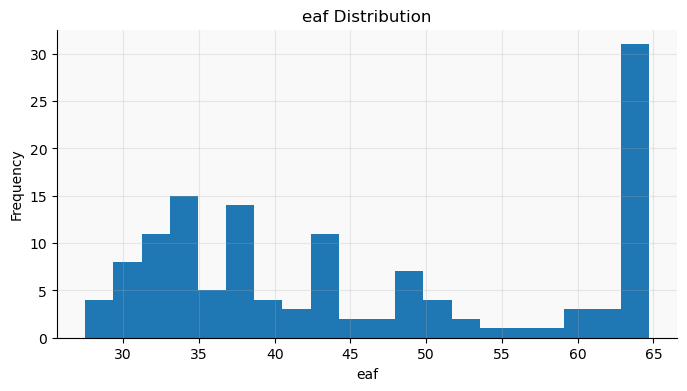

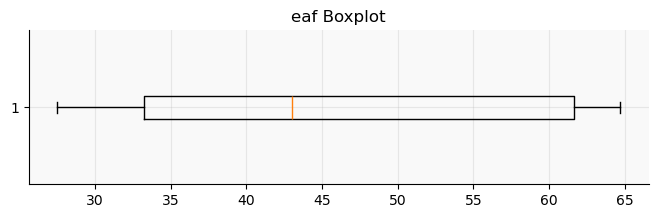


pipeline_down
count    132.000000
mean       6.250000
std        2.155678
min        3.000000
25%        4.000000
50%        7.000000
75%        8.000000
max       11.000000
Name: pipeline_down, dtype: float64
Skewness: 0.02
Kurtosis: -1.21


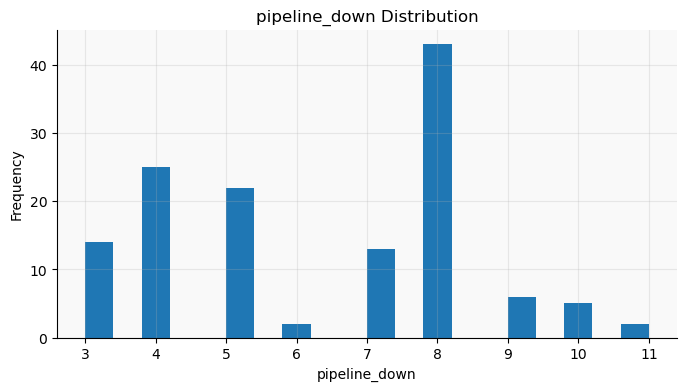

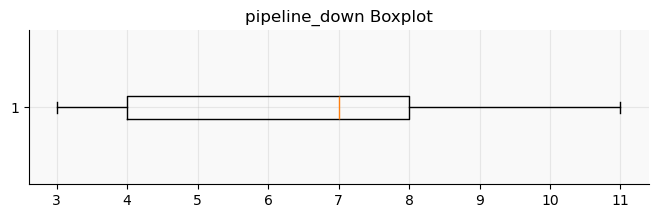


Gas_constraint
count    1.320000e+02
mean     1.127652e+06
std      8.902601e+05
min      0.000000e+00
25%      4.298178e+05
50%      1.329475e+06
75%      1.452000e+06
max      4.739451e+06
Name: Gas_constraint, dtype: float64
Skewness: 0.90
Kurtosis: 1.66


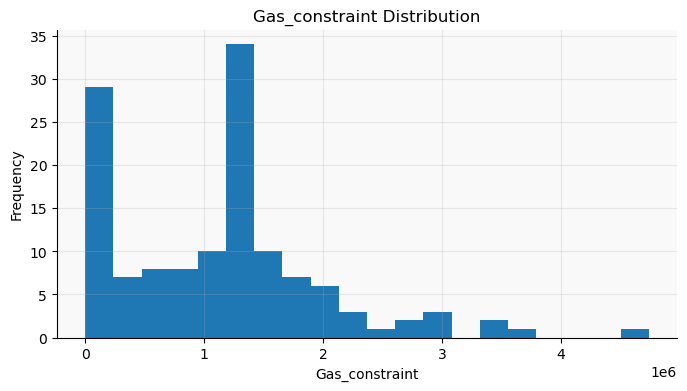

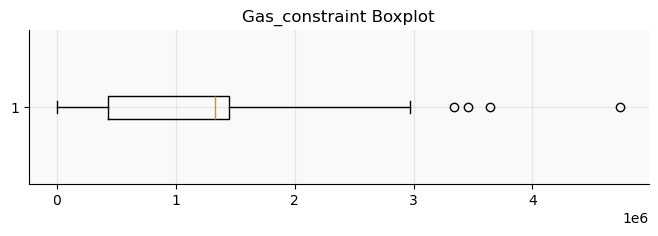


Transmission_constraint
count       132.000000
mean      59599.677159
std       30646.480971
min           0.000000
25%       37200.000000
50%       59683.893800
75%       74344.913953
max      148800.000000
Name: Transmission_constraint, dtype: float64
Skewness: 0.33
Kurtosis: 1.11


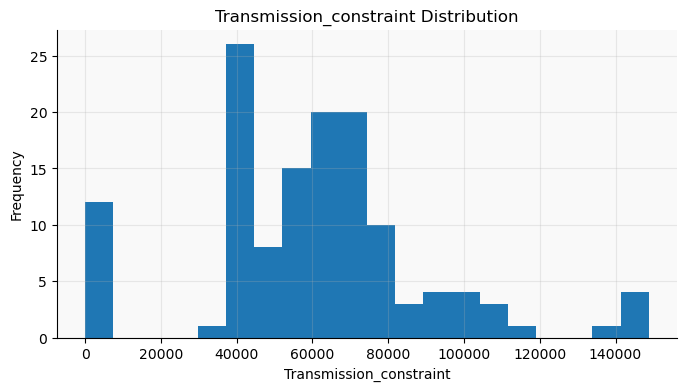

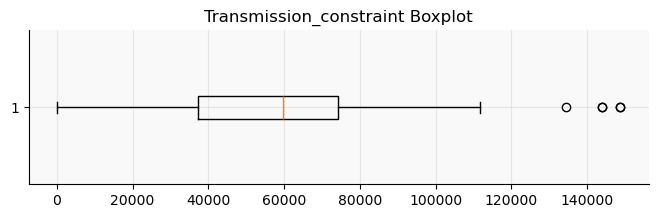


Distribution_constraint
count    1.320000e+02
mean     6.377935e+06
std      1.578868e+07
min      0.000000e+00
25%      7.440000e+04
50%      9.949421e+05
75%      2.326204e+06
max      5.913875e+07
Name: Distribution_constraint, dtype: float64
Skewness: 2.81
Kurtosis: 6.22


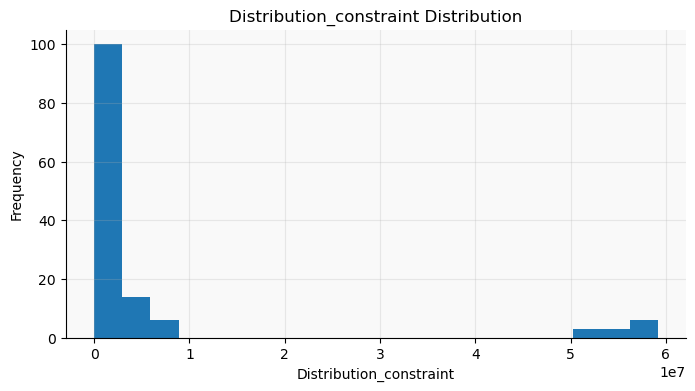

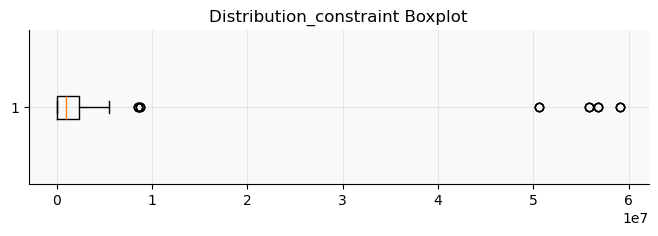


market_shortfall
count    1.320000e+02
mean     5.722014e+10
std      4.104253e+10
min      9.973333e+09
25%      2.862500e+10
50%      4.372598e+10
75%      7.140555e+10
max      1.910000e+11
Name: market_shortfall, dtype: float64
Skewness: 1.81
Kurtosis: 3.09


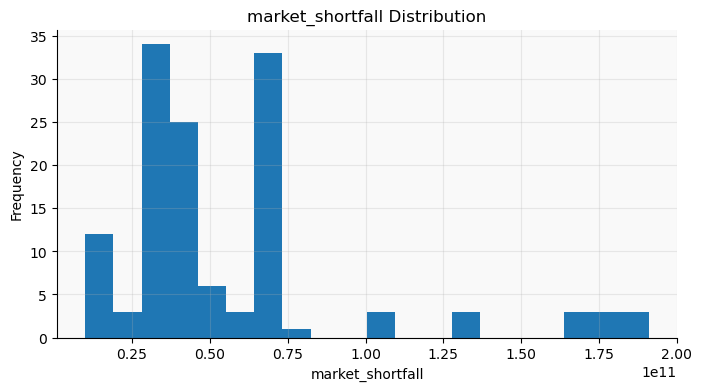

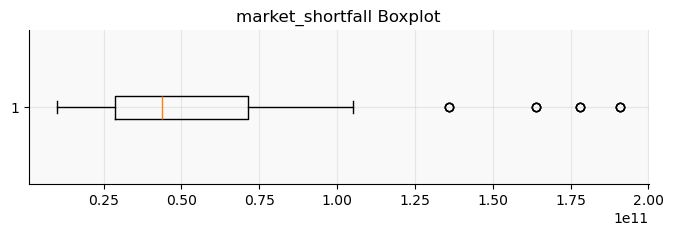


ATC&C
count    132.000000
mean      46.830919
std        6.493546
min       33.270000
25%       42.000000
50%       46.850000
75%       54.100000
max       56.000000
Name: ATC&C, dtype: float64
Skewness: -0.38
Kurtosis: -0.90


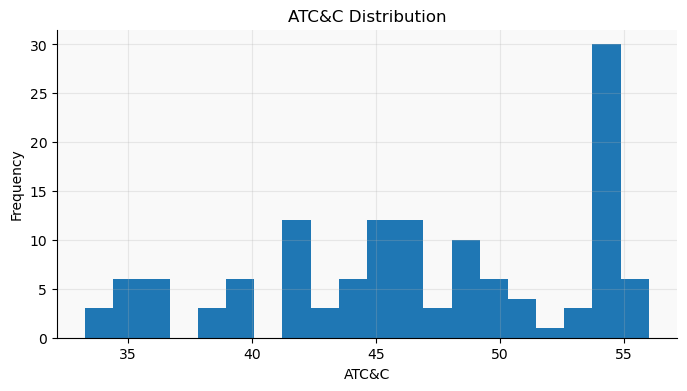

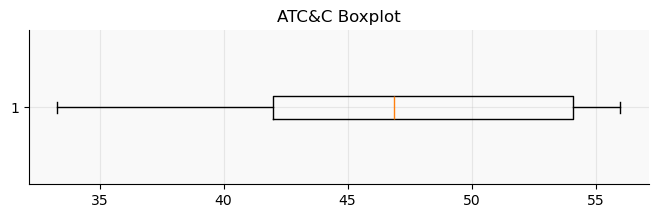


nbet_ratio
count    132.000000
mean      58.222746
std       23.012147
min       18.250000
25%       42.000000
50%       45.000000
75%       77.460000
max       96.930000
Name: nbet_ratio, dtype: float64
Skewness: 0.25
Kurtosis: -1.37


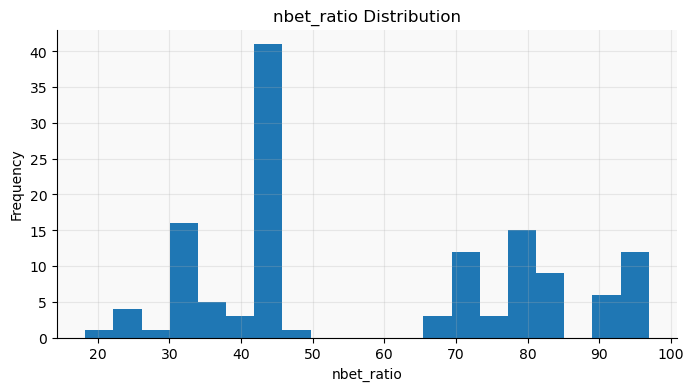

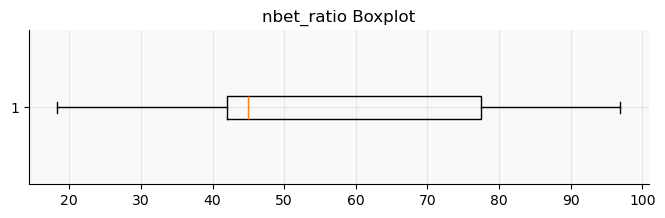


freq_collapse
count    132.000000
mean       1.750000
std        2.235641
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        6.000000
Name: freq_collapse, dtype: float64
Skewness: 1.19
Kurtosis: -0.25


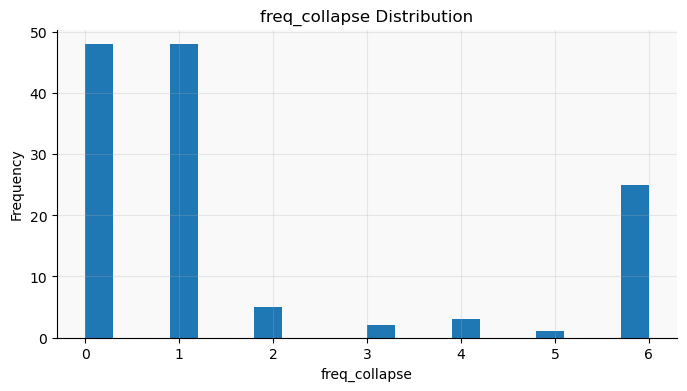

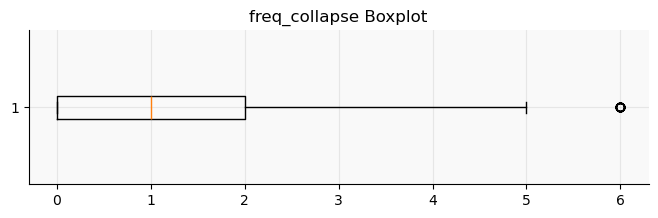


ghi
count    132.000000
mean       5.290936
std        0.613740
min        3.600440
25%        5.038325
50%        5.312400
75%        5.751525
max        6.264850
Name: ghi, dtype: float64
Skewness: -0.92
Kurtosis: 0.39


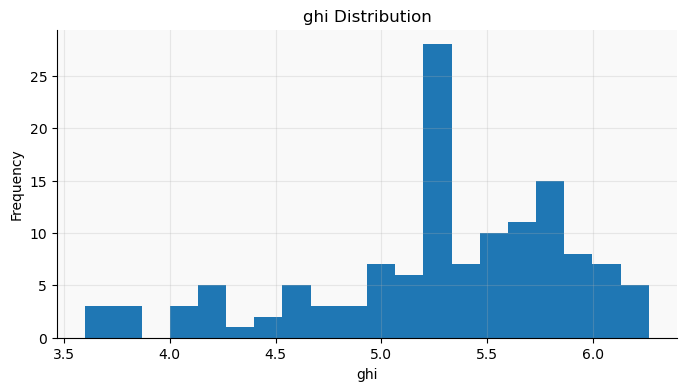

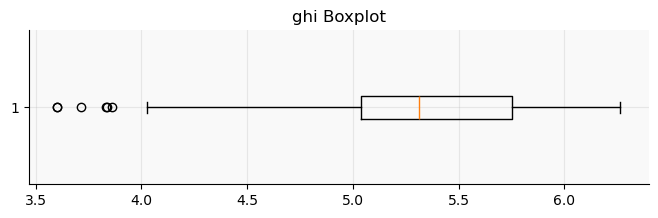


dni
count    132.000000
mean       3.026376
std        1.186322
min        0.892970
25%        2.142575
50%        3.188150
75%        3.435250
max        5.971370
Name: dni, dtype: float64
Skewness: 0.35
Kurtosis: -0.19


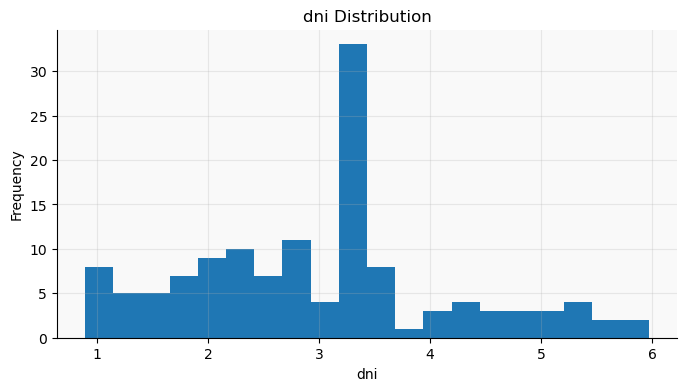

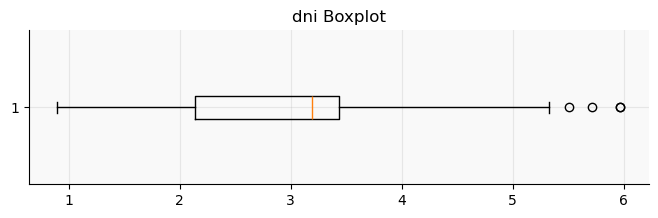


temp_c
count    132.000000
mean      25.778771
std        1.725758
min       22.880900
25%       24.810000
50%       25.200000
75%       26.512500
max       30.798000
Name: temp_c, dtype: float64
Skewness: 1.07
Kurtosis: 0.72


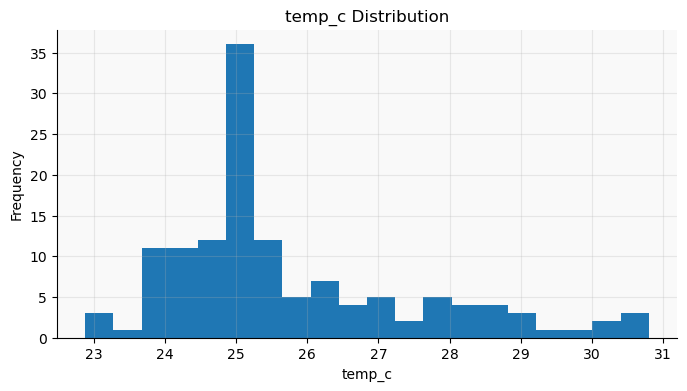

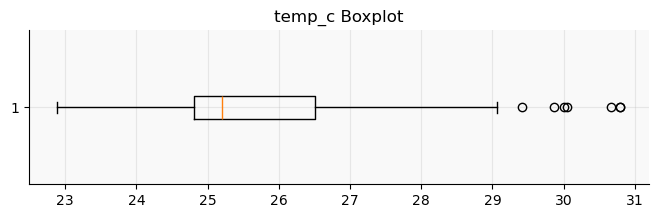


precip_mm
count    132.000000
mean      83.471555
std      104.541025
min        0.000000
25%        0.000000
50%       26.970000
75%      151.125000
max      387.642600
Name: precip_mm, dtype: float64
Skewness: 1.14
Kurtosis: 0.34


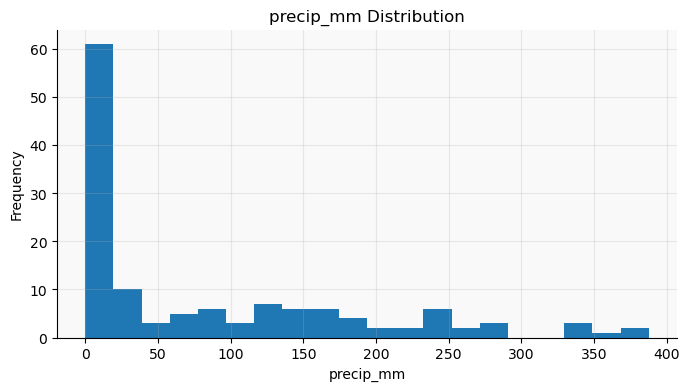

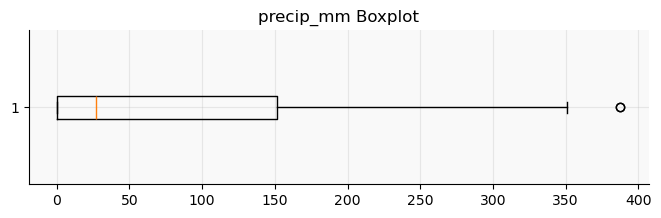


aerosol_od
count    132.000000
mean       0.563371
std        0.162603
min        0.283000
25%        0.450000
50%        0.540000
75%        0.690000
max        1.129000
Name: aerosol_od, dtype: float64
Skewness: 0.53
Kurtosis: 0.27


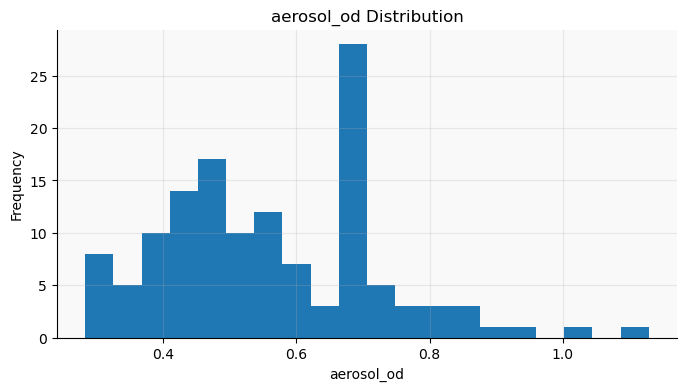

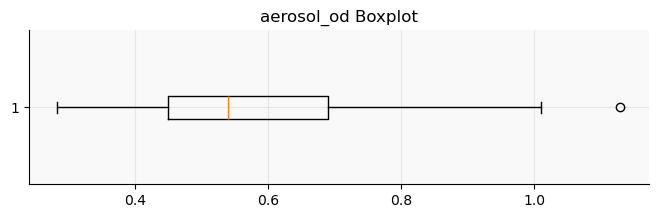


harmattan
count    132.000000
mean       0.522727
std        0.501386
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: harmattan, dtype: float64
Skewness: -0.09
Kurtosis: -2.02


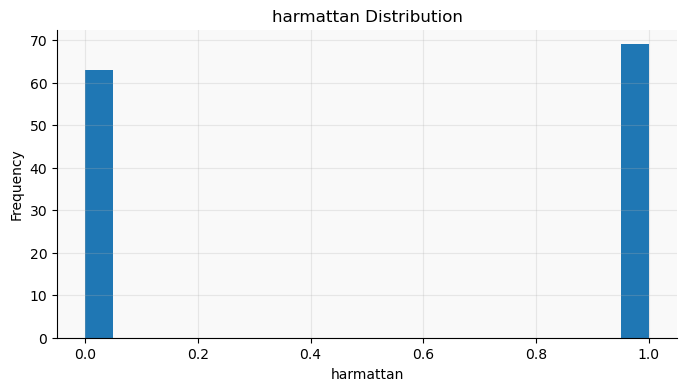

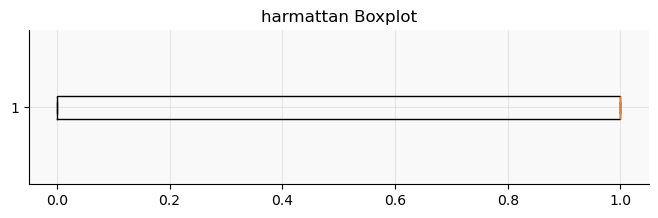

In [5]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1A — DISTRIBUTION DIAGNOSTICS
# Review distributions before any outlier treatment
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

# Variables likely to contain operational outliers
review_vars = [

    # DEPENDENT VARIABLES
    'gas_price',
    'gas_cf',
    'solar_cf',

    # GAS MARKET
    'brent',
    'usdngn',
    'ttf_jkm',
    'jkm_netback',
    'inflation',
    'fx_reserves',

    # GAS CF DRIVERS
    'gas_to_power',
    'domestic_alloc',
    'eaf',
    'pipeline_down',

    # CONSTRAINTS
    'Gas_constraint',
    'Transmission_constraint',
    'Distribution_constraint',

    # POWER MARKET
    'market_shortfall',
    'ATC&C',
    'nbet_ratio',
    'freq_collapse',

    # SOLAR RESOURCE
    'ghi',
    'dni',
    'temp_c',
    'precip_mm',
    'aerosol_od',
    'harmattan'
]

available_vars = [v for v in review_vars if v in df.columns]

print("Variables found:")
print(available_vars)
    
for var in available_vars:

    s = pd.to_numeric(df[var], errors='coerce').dropna()

    if len(s) < 10:
        continue

    print('\n' + '='*70)
    print(var)

    print(s.describe())

    print(f'Skewness: {s.skew():.2f}')
    print(f'Kurtosis: {s.kurtosis():.2f}')

    plt.figure(figsize=(8,4))
    plt.hist(s, bins=20)
    plt.title(f'{var} Distribution')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

    plt.figure(figsize=(8,2))
    plt.boxplot(s, vert=False)
    plt.title(f'{var} Boxplot')
    plt.show()

In [6]:
# ═══════════════════════════════════════════════════════════════════════
# OUTLIER DIAGNOSTICS
# ═══════════════════════════════════════════════════════════════════════

review_vars = [
    'solar_cf',
    'gas_cf',
    'ghi',
    'dni',
    'temp_c',
    'precip_mm',
    'aerosol_od',
    'nbet_ratio',
    'receivables'
]

for var in review_vars:

    if var not in df.columns:
        continue

    s = pd.to_numeric(df[var], errors='coerce').dropna()

    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((s < lower) | (s > upper)).sum()

    print(
        f"{var:<15} "
        f"Outliers={outliers:>3} "
        f"({100*outliers/len(s):.1f}%)"
    )

solar_cf        Outliers=  0 (0.0%)
gas_cf          Outliers=  0 (0.0%)
ghi             Outliers=  6 (4.5%)
dni             Outliers=  4 (3.0%)
temp_c          Outliers=  7 (5.3%)
precip_mm       Outliers=  2 (1.5%)
aerosol_od      Outliers=  1 (0.8%)
nbet_ratio      Outliers=  0 (0.0%)
receivables     Outliers= 38 (28.8%)


In [7]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1A — DESCRIPTIVE STATISTICS
# Review all variables in master dataframe
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

print("=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)

# Numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns

desc_stats = pd.DataFrame(index=num_cols)

desc_stats['count'] = df[num_cols].count()
desc_stats['missing'] = df[num_cols].isna().sum()
desc_stats['mean'] = df[num_cols].mean()
desc_stats['median'] = df[num_cols].median()
desc_stats['std'] = df[num_cols].std()
desc_stats['min'] = df[num_cols].min()
desc_stats['max'] = df[num_cols].max()
desc_stats['skew'] = df[num_cols].skew()
desc_stats['kurtosis'] = df[num_cols].kurt()

# Round for readability
desc_stats = desc_stats.round(4)

print(desc_stats)

# Save for thesis documentation
desc_stats.to_csv('descriptive_statistics.csv')

print("\nSaved: descriptive_statistics.csv")
print(f"Variables analysed: {len(num_cols)}")

DESCRIPTIVE STATISTICS
                          count  missing          mean        median  \
brent                       132        0  6.770140e+01  6.536380e+01   
usdngn                      132        0  6.155868e+02  3.690000e+02   
ttf_jkm                     132        0  1.135130e+01  7.204600e+00   
jkm_netback                 132        0  1.113910e+01  1.025850e+01   
ghi                         132        0  5.290900e+00  5.312400e+00   
dni                         132        0  3.026400e+00  3.188200e+00   
temp_c                      132        0  2.577880e+01  2.520000e+01   
precip_mm                   132        0  8.347160e+01  2.697000e+01   
aerosol_od                  132        0  5.634000e-01  5.400000e-01   
fx_reserves                 132        0  3.615950e+01  3.603150e+01   
inflation                   132        0  1.868480e+01  1.640000e+01   
gas_price                   132        0  1.946100e+00  2.050000e+00   
harmattan                   132        0 

CORRELATION MATRIX SAVED
Variables analysed: 38
Saved: correlation_matrix.csv

HIGH CORRELATIONS (|ρ| ≥ 0.7)
                 Variable_1               Variable_2  Correlation
69  Total_E_Billed_by_Disco    Total_E_paid_to_Disco     0.998682
71  Total_E_Billed_by_Disco  Distribution_constraint     0.994050
73    Total_E_paid_to_Disco  Distribution_constraint     0.990634
68              receivables  Distribution_constraint     0.989732
65              receivables  Total_E_Billed_by_Disco     0.985426
..                      ...                      ...          ...
21                inflation                    ATC&C    -0.712957
14                      ghi                precip_mm    -0.712727
51                      eaf            freq_collapse     0.710852
43             gas_to_power           domestic_alloc    -0.710411
26                inflation            disco_collect     0.702976

[76 rows x 3 columns]


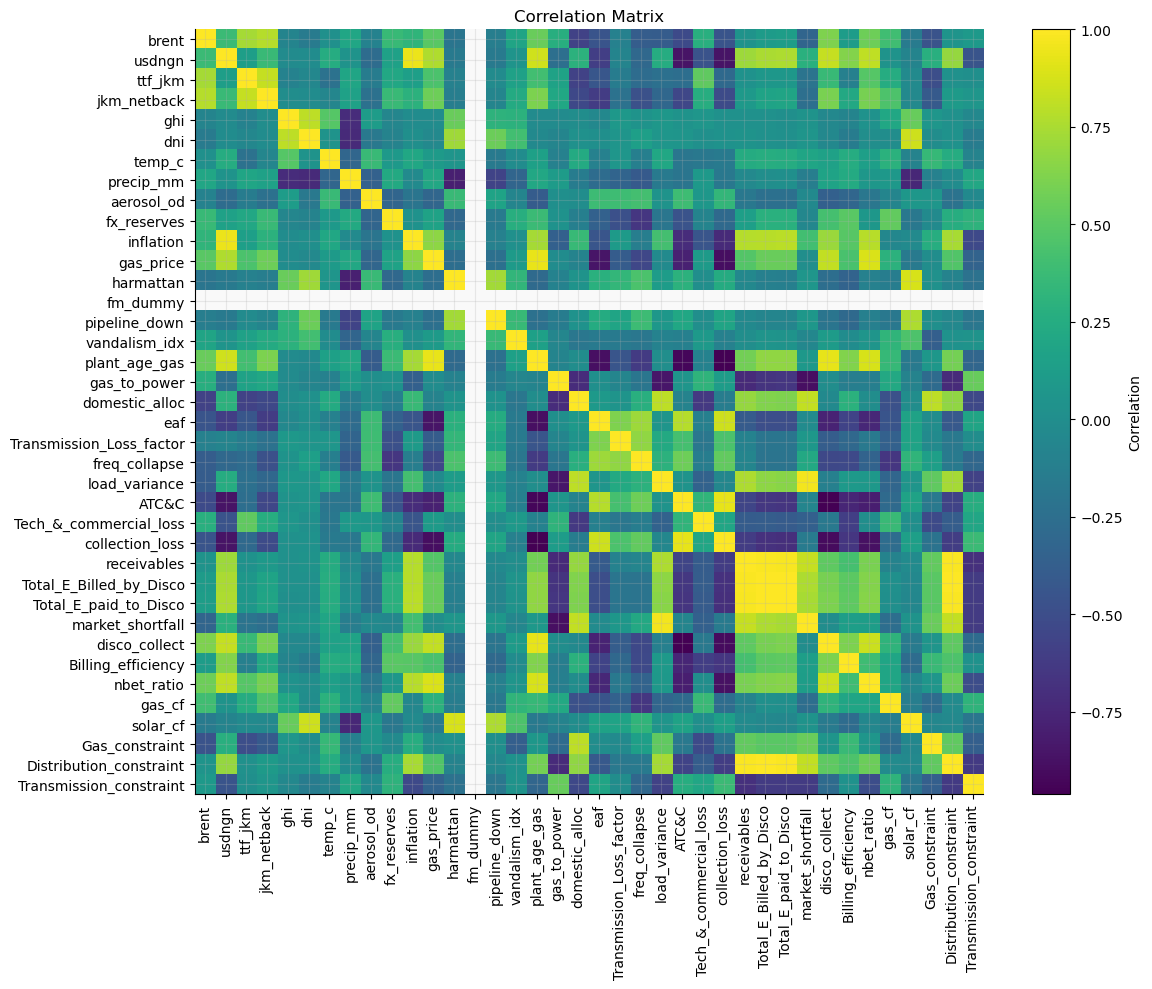

In [8]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 1B — CORRELATION DIAGNOSTICS
# Multicollinearity screening before econometric modelling
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Numeric variables only
num_df = df.select_dtypes(include=[np.number])

# Pearson correlation matrix
corr_matrix = num_df.corr(method='pearson')

# Save full matrix
corr_matrix.to_csv('correlation_matrix.csv')

print("=" * 80)
print("CORRELATION MATRIX SAVED")
print("=" * 80)

print(f"Variables analysed: {corr_matrix.shape[0]}")
print("Saved: correlation_matrix.csv")

# ------------------------------------------------------------
# High-correlation pairs
# ------------------------------------------------------------

threshold = 0.70

high_corr = []

for i in range(len(corr_matrix.columns)):

    for j in range(i+1, len(corr_matrix.columns)):

        corr_val = corr_matrix.iloc[i, j]

        if abs(corr_val) >= threshold:

            high_corr.append([
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_val
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=['Variable_1', 'Variable_2', 'Correlation']
)

high_corr_df = high_corr_df.sort_values(
    by='Correlation',
    key=lambda s: abs(s),
    ascending=False
)

print("\n" + "="*80)
print(f"HIGH CORRELATIONS (|ρ| ≥ {threshold})")
print("="*80)

print(high_corr_df)

high_corr_df.to_csv(
    'high_correlations.csv',
    index=False
)

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(12,10))

plt.imshow(
    corr_matrix,
    aspect='auto'
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation Matrix')

plt.tight_layout()

plt.show()

In [9]:
df.columns

Index(['brent', 'usdngn', 'ttf_jkm', 'jkm_netback', 'ghi', 'dni', 'temp_c',
       'precip_mm', 'aerosol_od', 'fx_reserves', 'inflation', 'gas_price',
       'harmattan', 'fm_dummy', 'pipeline_down', 'vandalism_idx',
       'plant_age_gas', 'gas_to_power', 'domestic_alloc', 'eaf',
       'Transmission_Loss_factor', 'freq_collapse', 'load_variance', 'ATC&C',
       'Tech_&_commercial_loss', 'collection_loss', 'receivables',
       'Total_E_Billed_by_Disco', 'Total_E_paid_to_Disco', 'market_shortfall',
       'disco_collect', 'Billing_efficiency', 'nbet_ratio', 'gas_cf',
       'solar_cf', 'Gas_constraint', 'Distribution_constraint',
       'Transmission_constraint'],
      dtype='str')

In [10]:
# ============================================================
# VARIANCE INFLATION FACTOR (VIF) DIAGNOSTICS
# ===========================================================
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def compute_vif(df, variables, model_name):

    X = df[variables].copy()

    # remove rows with missing values
    X = X.dropna()

    # add intercept
    X = add_constant(X)

    vif_df = pd.DataFrame()

    vif_df["Variable"] = X.columns

    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]

    print("\n" + "="*70)
    print(model_name)
    print("="*70)

    print(
        vif_df
        .sort_values("VIF", ascending=False)
        .round(2)
        .to_string(index=False)
    )

    return vif_df


# ============================================================
# GAS PRICE MODEL
# ============================================================

gas_price_vars = [
    "usdngn",
    "brent",
    "ttf_jkm",
    "jkm_netback",
    "fx_reserves"
]

compute_vif(
    df,
    gas_price_vars,
    "GAS PRICE MODEL"
)

# ===========================================================
# Receivables
# ===========================================================

receivables_vars = [
    "Total_E_Billed_by_Disco",
    "disco_collect",
    "nbet_ratio",
    "gas_cf"
]

compute_vif(
    df,
    receivables_vars, 
    "RECEIVABLES MODEL"
)


# ============================================================
# GAS CAPACITY FACTOR MODEL
# ============================================================

gas_cf_vars = [
    "eaf",
    "domestic_alloc",
    "gas_to_power",
    "pipeline_down",
    "vandalism_idx",
    "freq_collapse"
]

compute_vif(
    df,
    gas_cf_vars,
    "GAS CF MODEL"
)

# ============================================================
# EAF
# ============================================================

eaf_vars = [
    "gas_to_power",
    "vandalism_idx",
    "pipeline_down",
    "plant_age_gas",
    "freq_collapse"
]

compute_vif(
    df,
    eaf_vars,
    "EAF MODEL"
)

# ============================================================
# SOLAR CAPACITY FACTOR MODEL
# ============================================================

solar_cf_vars = [
    "dni",
    "harmattan",
    "precip_mm",
    "aerosol_od",
    "temp_c"
]

compute_vif(
    df,
    solar_cf_vars,
    "SOLAR CF MODEL"
)


GAS PRICE MODEL
   Variable   VIF
      const 55.65
jkm_netback  4.88
    ttf_jkm  4.20
      brent  3.09
     usdngn  1.39
fx_reserves  1.24

RECEIVABLES MODEL
               Variable    VIF
                  const 263.06
          disco_collect   3.87
             nbet_ratio   3.78
Total_E_Billed_by_Disco   1.78
                 gas_cf   1.17

GAS CF MODEL
      Variable     VIF
         const 5429.99
 freq_collapse    2.61
domestic_alloc    2.31
  gas_to_power    2.25
           eaf    2.12
 pipeline_down    1.52
 vandalism_idx    1.43

EAF MODEL
     Variable     VIF
        const 3426.91
freq_collapse    2.14
plant_age_gas    1.74
pipeline_down    1.52
vandalism_idx    1.34
 gas_to_power    1.12

SOLAR CF MODEL
  Variable    VIF
     const 398.46
       dni   5.94
 harmattan   5.05
 precip_mm   4.59
aerosol_od   3.24
    temp_c   1.47


,Variable,VIF
0,const,398.458512
1,dni,5.943443
2,harmattan,5.046224
3,precip_mm,4.586546
4,aerosol_od,3.236329
5,temp_c,1.465773


---
## Cell 2 — Stationarity Testing (ADF + KPSS)

In [11]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 2 — STATIONARITY DIAGNOSTICS
# ADF + KPSS
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.stattools import adfuller, kpss

stationarity_vars = {

    # GAS PRICE MODEL
    'gas_price'             : df['gas_price'],
    'brent'                 : df['brent'],
    'usdngn'                : df['usdngn'],
    'ttf_jkm'               : df['ttf_jkm'],
    'fx_reserves'           : df['fx_reserves'],
    'jkm_netback'           : df['jkm_netback'],

    # RECEIVABLES MODEL
    'receivables'           : df['receivables'],
    'nbet_ratio'            : df['nbet_ratio'],
    'disco_collect'         : df['disco_collect'],
    'receivables'           : df['receivables'],
    
    # EAF MODEL
    'eaf'                   : df['eaf'],
    'pipeline_down'         : df['pipeline_down'],
    'vandalism_idx'         : df['vandalism_idx'],
    'gas_to_power'          : df['gas_to_power'],
    'plant_age_gas'         : df['plant_age_gas'],
    'freq_collapse'         : df['freq_collapse'],

     # GAS CF MODEL
    'gas_cf'                : df['gas_cf'],
    'eaf'                   : df['eaf'],
    'pipeline_down'         : df['pipeline_down'],
    'vandalism_idx'         : df['vandalism_idx'],
    'freq_collapse'         : df['freq_collapse'],    
    'domestic_alloc'        : df['domestic_alloc'],

    # SOLAR CF MODEL
    'solar_cf'              : df['solar_cf'],
    'dni'                   : df['dni'],
    'precip_mm'             : df['precip_mm'],
    'harmattan'             : df['harmattan'],
    'aerosol_od'            : df['aerosol_od'],
    'temp_c'                : df['temp_c']
}

results = []

for name, series in stationarity_vars.items():

    s = pd.Series(series).dropna()

    try:

        adf_p = adfuller(
            s,
            autolag='AIC'
        )[1]

        kpss_p = kpss(
            s,
            regression='ct',
            nlags='auto'
        )[1]

        if adf_p < 0.05 and kpss_p > 0.05:
            verdict = 'I(0)'
            action = 'LEVEL'

        elif adf_p > 0.05 and kpss_p < 0.05:
            verdict = 'I(1)'
            action = 'DIFFERENCE'

        else:
            verdict = 'Ambiguous'
            action = 'CHECK'

        results.append([
            name,
            round(adf_p,4),
            round(kpss_p,4),
            verdict,
            action
        ])

    except Exception as ex:

        results.append([
            name,
            np.nan,
            np.nan,
            f'Error: {ex}'
        ])

stationarity_results = pd.DataFrame(
    results,
    columns=[
        'Variable',
        'ADF_p',
        'KPSS_p',
        'Conclusion',
        'Action'
    ]
)
print("\nSUMMARY")
print(
    stationarity_results["Conclusion"]
    .value_counts()
)
print(stationarity_results)

stationarity_results.to_csv(
    'stationarity_results.csv',
    index=False
)

C:\Users\pc\AppData\Local\Temp\ipykernel_21832\540169775.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_21832\540169775.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_21832\540169775.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_21832\540169775.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(
C:\Users


SUMMARY
Conclusion
I(1)         11
Ambiguous    11
I(0)          1
Name: count, dtype: int64
          Variable   ADF_p  KPSS_p Conclusion      Action
0        gas_price  0.8509  0.0181       I(1)  DIFFERENCE
1            brent  0.1781  0.1000  Ambiguous       CHECK
2           usdngn  0.8029  0.0100       I(1)  DIFFERENCE
3          ttf_jkm  0.0743  0.0810  Ambiguous       CHECK
4      fx_reserves  0.3363  0.0100       I(1)  DIFFERENCE
5      jkm_netback  0.2136  0.1000  Ambiguous       CHECK
6      receivables  0.9827  0.0100       I(1)  DIFFERENCE
7       nbet_ratio  0.8554  0.0100       I(1)  DIFFERENCE
8    disco_collect  0.8986  0.0943  Ambiguous       CHECK
9              eaf  0.5124  0.0100       I(1)  DIFFERENCE
10   pipeline_down  0.1540  0.1000  Ambiguous       CHECK
11   vandalism_idx  0.0000  0.1000       I(0)       LEVEL
12    gas_to_power  0.6805  0.0100       I(1)  DIFFERENCE
13   plant_age_gas  0.9585  0.0100       I(1)  DIFFERENCE
14   freq_collapse  0.2591  0.0100  

C:\Users\pc\AppData\Local\Temp\ipykernel_21832\540169775.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_21832\540169775.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_21832\540169775.py:62: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 2B — RESOLVE AMBIGUOUS STATIONARITY RESULTS
# KPSS (LEVEL STATIONARITY)
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.stattools import adfuller, kpss

ambiguous_vars = stationarity_results.loc[
    stationarity_results["Conclusion"] == "Ambiguous",
    "Variable"
].tolist()

results_2b = []

for var in ambiguous_vars:

    s = df[var].dropna()

    try:

        adf_p = adfuller(
            s,
            autolag="AIC"
        )[1]

        kpss_p = kpss(
            s,
            regression="c",
            nlags="auto"
        )[1]

        if adf_p < 0.05 and kpss_p > 0.05:

            verdict = "I(0)"
            action = "LEVEL"

        elif adf_p > 0.05 and kpss_p < 0.05:

            verdict = "I(1)"
            action = "DIFFERENCE"

        else:

            verdict = "Still Ambiguous"
            action = "VISUAL_CHECK"

        results_2b.append([
            var,
            round(adf_p, 4),
            round(kpss_p, 4),
            verdict,
            action
        ])

    except Exception as ex:

        results_2b.append([
            var,
            np.nan,
            np.nan,
            f"Error: {ex}",
            "CHECK"
        ])

cell2b_results = pd.DataFrame(
    results_2b,
    columns=[
        "Variable",
        "ADF_p",
        "KPSS_c_p",
        "Conclusion",
        "Action"
    ]
)

print("\nCELL 2B RESULTS")
print(cell2b_results)

print("\nSUMMARY")
print(cell2b_results["Conclusion"].value_counts())

cell2b_results.to_csv(
    "stationarity_results_cell2b.csv",
    index=False
)

C:\Users\pc\AppData\Local\Temp\ipykernel_21832\3623046122.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_21832\3623046122.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_21832\3623046122.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(
C:\Users\pc\AppData\Local\Temp\ipykernel_21832\3623046122.py:26: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(
C:\U


CELL 2B RESULTS
         Variable   ADF_p  KPSS_c_p       Conclusion        Action
0           brent  0.1781    0.0100             I(1)    DIFFERENCE
1         ttf_jkm  0.0743    0.0333             I(1)    DIFFERENCE
2     jkm_netback  0.2136    0.0100             I(1)    DIFFERENCE
3   disco_collect  0.8986    0.0100             I(1)    DIFFERENCE
4   pipeline_down  0.1540    0.0405             I(1)    DIFFERENCE
5        solar_cf  0.0726    0.1000  Still Ambiguous  VISUAL_CHECK
6             dni  0.1554    0.1000  Still Ambiguous  VISUAL_CHECK
7       precip_mm  0.2507    0.0750  Still Ambiguous  VISUAL_CHECK
8       harmattan  0.0701    0.0373             I(1)    DIFFERENCE
9      aerosol_od  0.5959    0.0100             I(1)    DIFFERENCE
10         temp_c  0.4544    0.1000  Still Ambiguous  VISUAL_CHECK

SUMMARY
Conclusion
I(1)               7
Still Ambiguous    4
Name: count, dtype: int64


---
# PART 2 MODELS

## Cell 3 — GAS PRICE

In [13]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 3 — ARDL BOUNDS TEST (GAS PRICE MODEL)
# FIXED ECONOMIC SPECIFICATION
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

from statsmodels.tsa.ardl import ARDL
from statsmodels.tsa.ardl import UECM

# --------------------------------------------------
# DATA
# --------------------------------------------------

ardl_df = df[[
    "gas_price",
    "usdngn",
    "brent",
    "ttf_jkm",
    "jkm_netback",
    "fx_reserves"
]].dropna()

# --------------------------------------------------
# LOG TRANSFORMS
# --------------------------------------------------

ardl_df["ln_gas_price"] = np.log(ardl_df["gas_price"])

ardl_df["ln_usdngn"] = np.log(
    np.clip(ardl_df["usdngn"], 1e-6, None)
)

ardl_df["ln_brent"] = np.log(
    np.clip(ardl_df["brent"], 1e-6, None)
)

ardl_df["ln_fx"] = np.log(
    np.clip(ardl_df["fx_reserves"], 1e-6, None)
)

# --------------------------------------------------
# DEPENDENT VARIABLE
# --------------------------------------------------

y = ardl_df["ln_gas_price"]

# --------------------------------------------------
# EXPLANATORY VARIABLES
# --------------------------------------------------

X = ardl_df[
    [
        "ln_usdngn",
        "ln_brent",
        "ttf_jkm",
        "jkm_netback",
        "ln_fx"
    ]
]

# --------------------------------------------------
# FIXED ARDL(1,1,1,1,1,1)
# --------------------------------------------------

ardl_model = ARDL(
    endog=y,
    lags=1,
    exog=X,
    order=1,
    trend="c"
)

ardl_res = ardl_model.fit()

print("=" * 70)
print("GAS PRICE ARDL RESULTS")
print("=" * 70)

print(ardl_res.summary())

# --------------------------------------------------
# UECM REPRESENTATION
# --------------------------------------------------

uecm = UECM.from_ardl(ardl_model)

uecm_res = uecm.fit()

print("\n")
print("=" * 70)
print("UECM RESULTS")
print("=" * 70)

print(uecm_res.summary())

# --------------------------------------------------
# BOUNDS TEST
# --------------------------------------------------

bounds = uecm_res.bounds_test(case=3)

print("\n")
print("=" * 70)
print("BOUNDS TEST")
print("=" * 70)

print(bounds)

print("\nF-STATISTIC:")
print(bounds.stat)

# --------------------------------------------------
# INTERPRETATION
# --------------------------------------------------

print("\n")
print("=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("Null Hypothesis: No Cointegration")

if bounds.stat > 5:
    print("\nStrong evidence of cointegration.")

elif bounds.stat > 3:
    print("\nPossible cointegration. Check critical values.")

else:
    print("\nLittle evidence of cointegration.")

# --------------------------------------------------
# ERROR CORRECTION TERM
# --------------------------------------------------

if "ci_summary" in dir(uecm_res):

    print("\n")
    print("=" * 70)
    print("LONG-RUN RELATIONSHIP")
    print("=" * 70)

    print(uecm_res.ci_summary())

GAS PRICE ARDL RESULTS
                                ARDL Model Results                                
Dep. Variable:               ln_gas_price   No. Observations:                  132
Model:             ARDL(1, 1, 1, 1, 1, 1)   Log Likelihood                 396.235
Method:                   Conditional MLE   S.D. of innovations              0.012
Date:                    Thu, 04 Jun 2026   AIC                           -766.470
Time:                            22:54:35   BIC                           -729.093
Sample:                        02-01-2015   HQIC                          -751.282
                             - 12-01-2025                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0298      0.035      0.846      0.399      -0.040       0.099
ln_gas_price.L1     1.0208      0.028     36.991      0.000  

In [14]:
# ══════════════════════════════════════════════════════════════════════
# CELL 4 — GAS PRICE MODEL
# SHORT-RUN DIFFERENCED REGRESSION
# ══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import statsmodels.api as sm

# --------------------------------------------------
# BUILD REGRESSION DATASET
# --------------------------------------------------

gp = df[
    [
        "gas_price",
        "usdngn",
        "brent",
        "ttf_jkm",
        "jkm_netback",
        "fx_reserves"
    ]
].copy()

# --------------------------------------------------
# LOG TRANSFORMS
# --------------------------------------------------

gp["ln_gas_price"] = np.log(
    np.clip(gp["gas_price"], 1e-6, None)
)

gp["ln_usdngn"] = np.log(
    np.clip(gp["usdngn"], 1e-6, None)
)

gp["ln_brent"] = np.log(
    np.clip(gp["brent"], 1e-6, None)
)

gp["ln_fx"] = np.log(
    np.clip(gp["fx_reserves"], 1e-6, None)
)

# --------------------------------------------------
# FIRST DIFFERENCES
# --------------------------------------------------

gp["d_ln_gas_price"] = gp["ln_gas_price"].diff()

gp["d_ln_usdngn"] = gp["ln_usdngn"].diff()

gp["d_ln_brent"] = gp["ln_brent"].diff()

gp["d_ln_fx"] = gp["ln_fx"].diff()

gp["d_ttf_jkm"] = gp["ttf_jkm"].diff()

gp["d_jkm_netback"] = gp["jkm_netback"].diff()

gp = gp.dropna()

# --------------------------------------------------
# DEPENDENT VARIABLE
# --------------------------------------------------

y = gp["d_ln_gas_price"]

# --------------------------------------------------
# EXPLANATORY VARIABLES
# --------------------------------------------------

X = gp[
    [
        "d_ln_usdngn",
        "d_ln_brent",
        "d_ttf_jkm",
        "d_jkm_netback",
        "d_ln_fx"
    ]
]

X = sm.add_constant(X)

# --------------------------------------------------
# OLS + NEWEY-WEST HAC
# --------------------------------------------------

model = sm.OLS(y, X)

results = model.fit(
    cov_type="HAC",
    cov_kwds={"maxlags":4}
)

# --------------------------------------------------
# OUTPUT
# --------------------------------------------------

print("=" * 80)
print("GAS PRICE MODEL")
print("SHORT-RUN DIFFERENCED REGRESSION")
print("=" * 80)

print(results.summary())

# --------------------------------------------------
# DIAGNOSTICS
# --------------------------------------------------

print("\n")
print("=" * 80)
print("KEY METRICS")
print("=" * 80)

print(f"Observations : {int(results.nobs)}")
print(f"R²           : {results.rsquared:.4f}")
print(f"Adj. R²      : {results.rsquared_adj:.4f}")
print(f"AIC          : {results.aic:.4f}")
print(f"BIC          : {results.bic:.4f}")

# --------------------------------------------------
# ECONOMIC INTERPRETATION TABLE
# --------------------------------------------------

coef_table = pd.DataFrame({
    "Coefficient": results.params,
    "Std_Error": results.bse,
    "t_stat": results.tvalues,
    "p_value": results.pvalues
})

print("\n")
print("=" * 80)
print("COEFFICIENTS")
print("=" * 80)

print(coef_table.round(4))

GAS PRICE MODEL
SHORT-RUN DIFFERENCED REGRESSION
                            OLS Regression Results                            
Dep. Variable:         d_ln_gas_price   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.265
Method:                 Least Squares   F-statistic:                    0.8482
Date:                Thu, 04 Jun 2026   Prob (F-statistic):              0.518
Time:                        22:58:44   Log-Likelihood:                 393.62
No. Observations:                 131   AIC:                            -775.2
Df Residuals:                     125   BIC:                            -758.0
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

---
## EAF MODEL


EAF DESCRIPTIVE STATISTICS
Mean : 45.8182
Min  : 27.4900
Max  : 64.7000
Std  : 13.0170

Full Summary
count    132.000000
mean      45.818217
std       13.016966
min       27.490000
25%       33.280000
50%       43.050000
75%       61.645713
max       64.700000
Name: eaf, dtype: float64


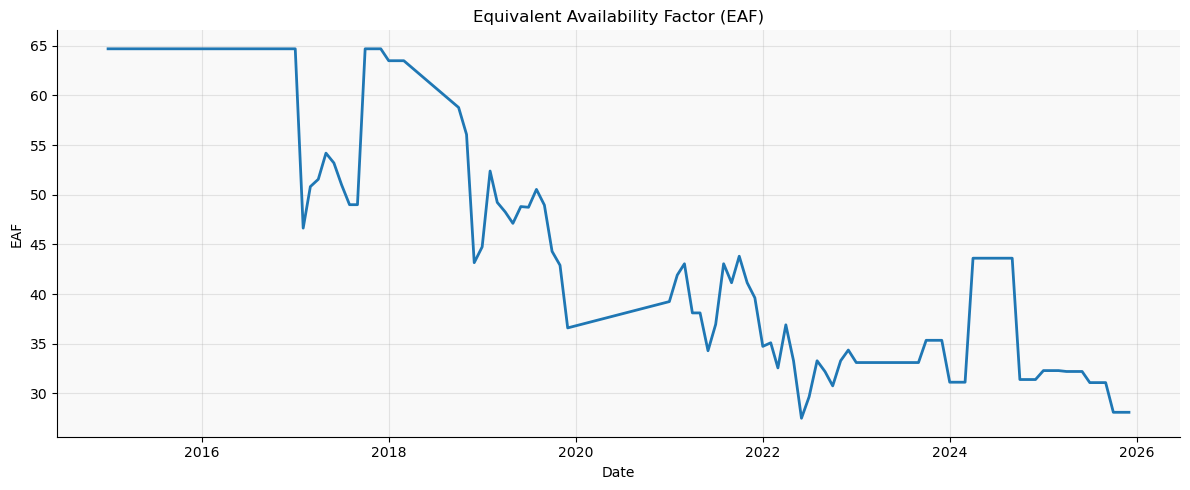


EAF CORRELATION MATRIX
                 eaf  pipeline_down  vandalism_idx  plant_age_gas  \
eaf            1.000          0.245         -0.159         -0.880   
pipeline_down  0.245          1.000          0.360         -0.228   
vandalism_idx -0.159          0.360          1.000          0.150   
plant_age_gas -0.880         -0.228          0.150          1.000   
gas_to_power   0.014         -0.134         -0.058         -0.074   
freq_collapse  0.711          0.384         -0.184         -0.622   

               gas_to_power  freq_collapse  
eaf                   0.014          0.711  
pipeline_down        -0.134          0.384  
vandalism_idx        -0.058         -0.184  
plant_age_gas        -0.074         -0.622  
gas_to_power          1.000         -0.192  
freq_collapse        -0.192          1.000  


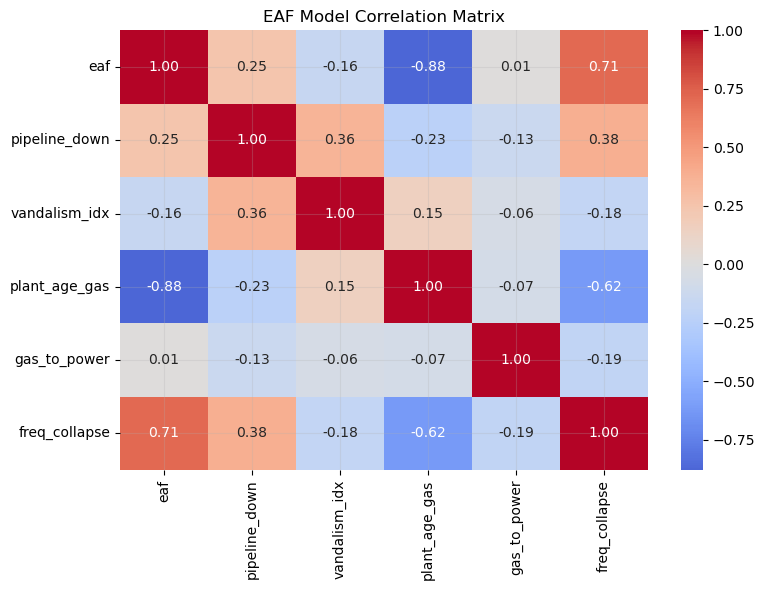

In [15]:
# ═══════════════════════════════════════════════════════════════════════
# EAF DIAGNOSTICS
# Descriptive Statistics + Time Series Plot + Correlation Matrix
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# VARIABLES
# -------------------------------------------------------------

eaf_vars = [
    'eaf',
    'pipeline_down',
    'vandalism_idx',
    'plant_age_gas',
    'gas_to_power',
    'freq_collapse'
]

eaf_df = df[eaf_vars].copy()

# -------------------------------------------------------------
# 1. EAF DESCRIPTIVE STATISTICS
# -------------------------------------------------------------

print("\n" + "="*70)
print("EAF DESCRIPTIVE STATISTICS")
print("="*70)

print(f"Mean : {eaf_df['eaf'].mean():.4f}")
print(f"Min  : {eaf_df['eaf'].min():.4f}")
print(f"Max  : {eaf_df['eaf'].max():.4f}")
print(f"Std  : {eaf_df['eaf'].std():.4f}")

print("\nFull Summary")
print(eaf_df['eaf'].describe())

# -------------------------------------------------------------
# 2. EAF TIME SERIES PLOT
# -------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    eaf_df['eaf'],
    linewidth=2
)

plt.title("Equivalent Availability Factor (EAF)")
plt.xlabel("Date")
plt.ylabel("EAF")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. EAF CORRELATION MATRIX
# -------------------------------------------------------------

corr_matrix = eaf_df.corr()

print("\n" + "="*70)
print("EAF CORRELATION MATRIX")
print("="*70)

print(corr_matrix.round(3))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("EAF Model Correlation Matrix")

plt.tight_layout()
plt.show()

In [16]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 6 — EAF ARDL LAG SELECTION
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ardl_select_order

# -------------------------------------------------------------
# DEPENDENT VARIABLE
# -------------------------------------------------------------

y = df["eaf"]

# -------------------------------------------------------------
# EXPLANATORY VARIABLES
# -------------------------------------------------------------

X = df[
    [
        "pipeline_down",
        "vandalism_idx",
        "plant_age_gas",
        "gas_to_power",
        "freq_collapse"
    ]
]

# -------------------------------------------------------------
# AUTOMATIC ARDL ORDER SELECTION
# -------------------------------------------------------------

sel = ardl_select_order(
    endog=y,
    maxlag=4,
    exog=X,
    maxorder=4,
    ic="aic",
    trend="c"
)

print("\n" + "="*70)
print("SELECTED ARDL ORDER")
print("="*70)

print(sel.model.ardl_order)

# -------------------------------------------------------------
# FIT SELECTED MODEL
# -------------------------------------------------------------

ardl_model = sel.model.fit()

print("\n" + "="*70)
print("ARDL SUMMARY")
print("="*70)

print(ardl_model.summary())


SELECTED ARDL ORDER
(1, 2, 1)

ARDL SUMMARY
                              ARDL Model Results                              
Dep. Variable:                    eaf   No. Observations:                  132
Model:                  ARDL(1, 2, 1)   Log Likelihood                -307.912
Method:               Conditional MLE   S.D. of innovations              2.538
Date:                Thu, 04 Jun 2026   AIC                            631.823
Time:                        23:03:17   BIC                            654.825
Sample:                    03-01-2015   HQIC                           641.170
                         - 12-01-2025                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               16.9521      8.673      1.955      0.053      -0.213      34.117
eaf.L1               0.8184      0.042     19.642      0.000       0

The full EAF ARDL MODEL doesn't perform better than the AIC-selceted specification above, i'll keep the later.

In [17]:
# ═══════════════════════════════════════════════════════════════════════
# EAF ARDL (AGE REMOVED, TREND INCLUDED)
# ═══════════════════════════════════════════════════════════════════════
y = df["eaf"]

X = df[
    [
        "pipeline_down",
        "vandalism_idx",
        "gas_to_power",
        "freq_collapse"
    ]
]

sel2 = ardl_select_order(
    endog=y,
    exog=X,
    maxlag=4,
    maxorder=4,
    ic="aic",
    trend="ct"
)

print("\nSELECTED ORDER")
print(sel2.model.ardl_order)

print("\nAR LAGS")
print(sel2.model.ar_lags)

print("\nDL LAGS")
print(sel2.model.dl_lags)

eaf_model_2 = sel2.model.fit()

print(eaf_model_2.summary())


SELECTED ORDER
(1, 0, 4)

AR LAGS
[1]

DL LAGS
{'vandalism_idx': [0], 'freq_collapse': [0, 1, 2, 3, 4]}
                              ARDL Model Results                              
Dep. Variable:                    eaf   No. Observations:                  132
Model:                  ARDL(1, 0, 4)   Log Likelihood                -331.678
Method:               Conditional MLE   S.D. of innovations              3.043
Date:                Thu, 04 Jun 2026   AIC                            683.356
Time:                        23:04:10   BIC                            712.108
Sample:                    05-01-2015   HQIC                           695.039
                         - 12-01-2025                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               11.4129      3.293      3.466      0.001       4.894      17.932
trend   

In [22]:
from statsmodels.tsa.ardl import UECM

forced_uecm = UECM.from_ardl(forced_eaf.model)

forced_uecm_res = forced_uecm.fit()

print(forced_uecm_res.summary())

                               UECM Model Results                              
Dep. Variable:                   D.eaf   No. Observations:                  132
Model:             UECM(1, 1, 1, 1, 1)   Log Likelihood                -333.521
Method:                Conditional MLE   S.D. of innovations             47.836
Date:                 Thu, 04 Jun 2026   AIC                            691.042
Time:                         23:17:28   BIC                            725.544
Sample:                     02-01-2015   HQIC                           705.062
                          - 12-01-2025                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  6.4934     16.681      0.389      0.698     -26.534      39.521
trend                 -0.0432      0.017     -2.525      0.013      -0.077      -0.009
eaf.L1      

In [23]:
forced_bt = forced_uecm_res.bounds_test(case=5)

print(forced_bt)

BoundsTestResult
Stat: 4.38034
Upper P-value: 0.0405
Lower P-value: 0.00444
Null: No Cointegration
Alternative: Possible Cointegration



In [24]:
# ═══════════════════════════════════════════════════════════════════════
# FORCED EAF MODEL
# Keep all engineering variables regardless of AIC selection
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ARDL

forced_eaf = ARDL(
    endog=df["eaf"],
    lags=1,
    exog=df[
        [
            "pipeline_down",
            "vandalism_idx",
            "gas_to_power",
            "freq_collapse"
        ]
    ],
    order=1,
    trend="ct"
).fit()

print("\n" + "="*70)
print("FORCED EAF MODEL")
print("="*70)

print(forced_eaf.summary())


FORCED EAF MODEL
                               ARDL Model Results                              
Dep. Variable:                     eaf   No. Observations:                  132
Model:             ARDL(1, 1, 1, 1, 1)   Log Likelihood                -333.521
Method:                Conditional MLE   S.D. of innovations              3.086
Date:                 Thu, 04 Jun 2026   AIC                            691.042
Time:                         23:23:49   BIC                            725.544
Sample:                     02-01-2015   HQIC                           705.062
                          - 12-01-2025                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.4934     16.681      0.389      0.698     -26.534      39.521
trend               -0.0432      0.017     -2.525      0.013      -0.077      -0.009
ea

Pipeline downtime, vandalism incidents, and gas-to-power allocation were initially included based on engineering considerations. However, when forced into the ARDL specification, these variables remained statistically insignificant and materially worsened model fit (higher AIC). Consequently, the final EAF specification retained only the statistically supported variables identified through ARDL lag selection.

---
## GAS CF MODEL


GAS CF DESCRIPTIVE STATISTICS
Mean : 27.4057
Min  : 22.8100
Max  : 34.6600
Std  : 3.2706

Full Summary
count    132.000000
mean      27.405734
std        3.270559
min       22.810000
25%       24.980000
50%       27.500000
75%       29.682500
max       34.660000
Name: gas_cf, dtype: float64


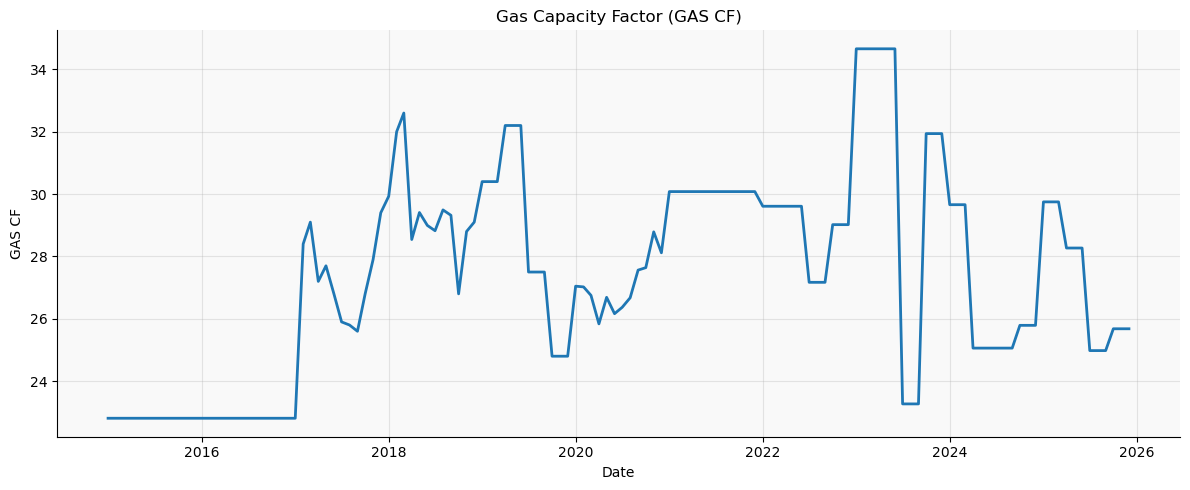


GAS CF CORRELATION MATRIX
                gas_cf    eaf  pipeline_down  vandalism_idx  domestic_alloc  \
gas_cf           1.000 -0.450         -0.174          0.322          -0.476   
eaf             -0.450  1.000          0.245         -0.159           0.103   
pipeline_down   -0.174  0.245          1.000          0.360           0.038   
vandalism_idx    0.322 -0.159          0.360          1.000          -0.185   
domestic_alloc  -0.476  0.103          0.038         -0.185           1.000   
freq_collapse   -0.652  0.711          0.384         -0.184           0.274   

                freq_collapse  
gas_cf                 -0.652  
eaf                     0.711  
pipeline_down           0.384  
vandalism_idx          -0.184  
domestic_alloc          0.274  
freq_collapse           1.000  


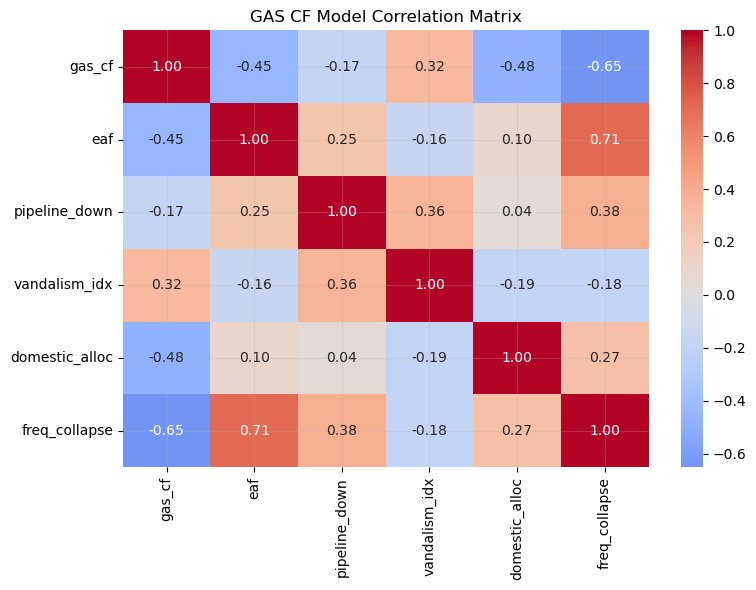

In [25]:
# ═══════════════════════════════════════════════════════════════════════
# GAS CF MODEL DIAGNOSTICS
# Descriptive Statistics + Time Series Plot + Correlation Matrix
# ═══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# VARIABLES
# -------------------------------------------------------------

gas_cf_vars = [
    'gas_cf',
    'eaf',
    'pipeline_down',
    'vandalism_idx',
    'domestic_alloc',
    'freq_collapse'
]

gas_cf_df = df[gas_cf_vars].copy()

# -------------------------------------------------------------
# 1. GAS CF DESCRIPTIVE STATISTICS
# -------------------------------------------------------------

print("\n" + "="*70)
print("GAS CF DESCRIPTIVE STATISTICS")
print("="*70)

print(f"Mean : {gas_cf_df['gas_cf'].mean():.4f}")
print(f"Min  : {gas_cf_df['gas_cf'].min():.4f}")
print(f"Max  : {gas_cf_df['gas_cf'].max():.4f}")
print(f"Std  : {gas_cf_df['gas_cf'].std():.4f}")

print("\nFull Summary")
print(gas_cf_df['gas_cf'].describe())

# -------------------------------------------------------------
# 2. GAS CF TIME SERIES PLOT
# -------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    gas_cf_df['gas_cf'],
    linewidth=2
)

plt.title("Gas Capacity Factor (GAS CF)")
plt.xlabel("Date")
plt.ylabel("GAS CF")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. GAS CF CORRELATION MATRIX
# -------------------------------------------------------------

corr_matrix = gas_cf_df.corr()

print("\n" + "="*70)
print("GAS CF CORRELATION MATRIX")
print("="*70)

print(corr_matrix.round(3))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("GAS CF Model Correlation Matrix")

plt.tight_layout()
plt.show()

In [26]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 6 — GAS CF ARDL LAG SELECTION
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ardl_select_order

# -------------------------------------------------------------
# DEPENDENT VARIABLE
# -------------------------------------------------------------

y = df["gas_cf"]

# -------------------------------------------------------------
# EXPLANATORY VARIABLES
# -------------------------------------------------------------

X = df[
    [
        "eaf",
        "pipeline_down",
        "vandalism_idx",
        "freq_collapse",
        "domestic_alloc"
    ]
]

# -------------------------------------------------------------
# AUTOMATIC ARDL ORDER SELECTION
# -------------------------------------------------------------

sel_gcf = ardl_select_order(
    endog=y,
    maxlag=4,
    exog=X,
    maxorder=4,
    ic="aic",
    trend="c"
)

print("\n" + "="*70)
print("SELECTED ARDL ORDER")
print("="*70)

print(sel_gcf.model.ardl_order)

print("\nAR LAGS")
print(sel_gcf.model.ar_lags)

print("\nDL LAGS")
print(sel_gcf.model.dl_lags)

# -------------------------------------------------------------
# FIT SELECTED MODEL
# -------------------------------------------------------------

gcf_model = sel_gcf.model.fit()

print("\n" + "="*70)
print("ARDL SUMMARY")
print("="*70)

print(gcf_model.summary())


SELECTED ARDL ORDER
(3, 1, 0, 1)

AR LAGS
[1, 2, 3]

DL LAGS
{'vandalism_idx': [0, 1], 'freq_collapse': [0], 'domestic_alloc': [0, 1]}

ARDL SUMMARY
                              ARDL Model Results                              
Dep. Variable:                 gas_cf   No. Observations:                  132
Model:               ARDL(3, 1, 0, 1)   Log Likelihood                -234.122
Method:               Conditional MLE   S.D. of innovations              1.486
Date:                Thu, 04 Jun 2026   AIC                            488.244
Time:                        23:25:37   BIC                            516.842
Sample:                    04-01-2015   HQIC                           499.864
                         - 12-01-2025                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                10.7278      2.235      4

In [27]:
# ═══════════════════════════════════════════════════════════════════════
# GAS CF ARDL FOR UECM / BOUNDS TEST
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ARDL

gcf_ardl_ecm = ARDL(
    endog=df["gas_cf"],
    lags=1,
    exog=df[
        [
            "vandalism_idx",
            "freq_collapse",
            "domestic_alloc"
        ]
    ],
    order=1,          # force lag 1 on every variable
    trend="c"
).fit()

print(gcf_ardl_ecm.summary())

                              ARDL Model Results                              
Dep. Variable:                 gas_cf   No. Observations:                  132
Model:               ARDL(1, 1, 1, 1)   Log Likelihood                -238.985
Method:               Conditional MLE   S.D. of innovations              1.500
Date:                Thu, 04 Jun 2026   AIC                            495.970
Time:                        23:26:13   BIC                            521.847
Sample:                    02-01-2015   HQIC                           506.485
                         - 12-01-2025                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 8.4254      1.970      4.277      0.000       4.526      12.325
gas_cf.L1             0.6617      0.064     10.284      0.000       0.534       0.789
vandalism_idx.L0      0.

In [28]:
from statsmodels.tsa.ardl import UECM

gcf_uecm = UECM.from_ardl(gcf_ardl_ecm.model)

gcf_uecm_res = gcf_uecm.fit()

print(gcf_uecm_res.summary())

                              UECM Model Results                              
Dep. Variable:               D.gas_cf   No. Observations:                  132
Model:               UECM(1, 1, 1, 1)   Log Likelihood                -238.985
Method:               Conditional MLE   S.D. of innovations             27.654
Date:                Thu, 04 Jun 2026   AIC                            495.970
Time:                        23:26:32   BIC                            521.847
Sample:                    02-01-2015   HQIC                           506.485
                         - 12-01-2025                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   8.4254      1.970      4.277      0.000       4.526      12.325
gas_cf.L1              -0.3383      0.064     -5.258      0.000      -0.466      -0.211
vandalism_idx.L1

In [29]:
gcf_bt = gcf_uecm_res.bounds_test(case=3)

print(gcf_bt)

BoundsTestResult
Stat: 10.83664
Upper P-value: 3.26e-07
Lower P-value: 1.01e-08
Null: No Cointegration
Alternative: Possible Cointegration



In [30]:
print(gcf_uecm_res.test_serial_correlation())
print(gcf_uecm_res.test_heteroskedasticity())
print(gcf_uecm_res.test_normality())

     Ljung-Box  LB P-value  DF
Lag                           
1          NaN         NaN NaN
2          NaN         NaN NaN
3          NaN         NaN NaN
4          NaN         NaN NaN
5          NaN         NaN NaN
6          NaN         NaN NaN
7          NaN         NaN NaN
8          NaN         NaN NaN
9          NaN         NaN NaN
10         NaN         NaN NaN
       ARCH-LM       P-value  DF
Lag                             
1    95.274212  1.657584e-22   1
2    98.102564  4.980797e-22   2
3    97.031038  6.757434e-21   3
4    96.189094  6.365562e-20   4
5    95.105249  5.674257e-19   5
6    93.978171  4.511729e-18   6
7    94.607614  1.396195e-17   7
8    93.471553  9.159467e-17   8
9    92.485464  5.157433e-16   9
10   91.337486  2.906965e-15  10
Jarque-Bera    3.296668
P-value        0.192370
Skewness       0.292371
Kurtosis       2.488096
dtype: float64


Empirical evidence suggests that system instability indicators exhibited greater explanatory power for Gas Capacity Factor than the expected fuel-supply and availability indicators over the study period.

ARCH-LM tests indicated heteroskedasticity in the residuals of the EAF and Gas CF equations. Given the forecasting orientation of the study and the stability of the key ECM coefficients, the models were retained while interpreting marginal coefficient significance with caution.

---
## Receivables Model


RECEIVABLES DESCRIPTIVE STATISTICS
Mean : 202337623963.8257
Min  : 53129000000.0000
Max  : 969000000000.0000
Std  : 230608685948.5654

Full Summary
count    1.320000e+02
mean     2.023376e+11
std      2.306087e+11
min      5.312900e+10
25%      1.172500e+11
50%      1.520000e+11
75%      1.532500e+11
max      9.690000e+11
Name: receivables, dtype: float64


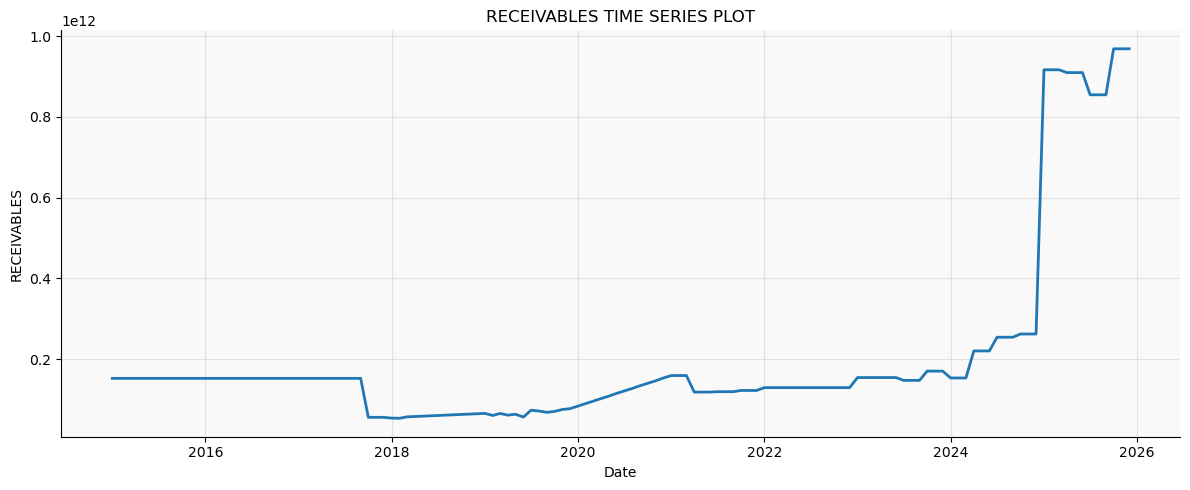


RECEIVABLES CORRELATION MATRIX
               receivables  nbet_ratio  disco_collect  gas_cf
receivables          1.000       0.603          0.510  -0.083
nbet_ratio           0.603       1.000          0.842   0.195
disco_collect        0.510       0.842          1.000   0.311
gas_cf              -0.083       0.195          0.311   1.000


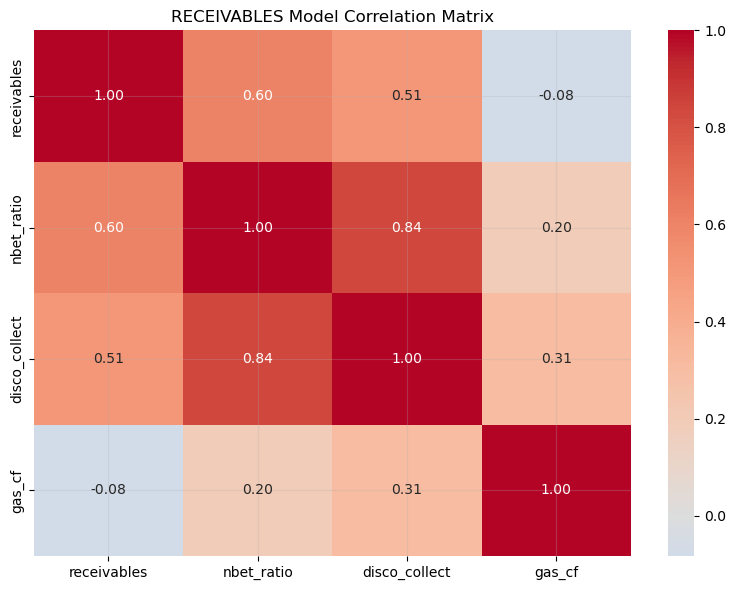

In [31]:
# ═══════════════════════════════════════════════════════════════════════
# RECEIVABLES MODEL DIAGNOSTICS
# Descriptive Statistics + Time Series Plot + Correlation Matrix
# ═══════════════════════════════════════════════════════════════════════
# -------------------------------------------------------------
# VARIABLES
# -------------------------------------------------------------

receivables_vars = [
    'receivables',
    'nbet_ratio',
    'disco_collect',
    'gas_cf'
]
receivables_df = df[receivables_vars].copy()

# -------------------------------------------------------------
# 1. RECEIVABLES DESCRIPTIVE STATISTICS
# -------------------------------------------------------------

print("\n" + "="*70)
print("RECEIVABLES DESCRIPTIVE STATISTICS")
print("="*70)

print(f"Mean : {receivables_df['receivables'].mean():.4f}")
print(f"Min  : {receivables_df['receivables'].min():.4f}")
print(f"Max  : {receivables_df['receivables'].max():.4f}")
print(f"Std  : {receivables_df['receivables'].std():.4f}")

print("\nFull Summary")
print(receivables_df['receivables'].describe())

# -------------------------------------------------------------
# 2. RECEIVABLES TIME SERIES PLOT
# -------------------------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    receivables_df['receivables'],
    linewidth=2
)

plt.title("RECEIVABLES TIME SERIES PLOT")
plt.xlabel("Date")
plt.ylabel("RECEIVABLES")

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 3. RECEIVABLES CORRELATION MATRIX
# -------------------------------------------------------------

corr_matrix = receivables_df.corr()

print("\n" + "="*70)
print("RECEIVABLES CORRELATION MATRIX")
print("="*70)

print(corr_matrix.round(3))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f'
)

plt.title("RECEIVABLES Model Correlation Matrix")

plt.tight_layout()
plt.show()

In [34]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 6 RECEIVABLES MODEL ARDL LAG SELECTION
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ardl_select_order

# -------------------------------------------------------------
# DEPENDENT VARIABLE
# -------------------------------------------------------------

y = df["receivables"]

# -------------------------------------------------------------
# EXPLANATORY VARIABLES
# -------------------------------------------------------------

X = df[
    [
        'receivables',
        'nbet_ratio',
        'disco_collect',
        'gas_cf'
    ]
]

# -------------------------------------------------------------
# AUTOMATIC ARDL ORDER SELECTION
# -------------------------------------------------------------

sel_receivables = ardl_select_order(
    endog=y,
    maxlag=4,
    exog=X,
    maxorder=4,
    ic="aic",
    trend="c"
)

print("\n" + "="*70)
print("SELECTED ARDL ORDER")
print("="*70)

print(sel_receivables.model.ardl_order)

print("\nAR LAGS")
print(sel_receivables.model.ar_lags)

print("\nDL LAGS")
print(sel_receivables.model.dl_lags)

# -------------------------------------------------------------
# FIT SELECTED MODEL
# -------------------------------------------------------------

receivables_model = sel_receivables.model.fit()

print("\n" + "="*70)
print("ARDL SUMMARY")
print("="*70)

print(receivables_model.summary())


SELECTED ARDL ORDER
(1, 1, 1, 1)

AR LAGS
[1]

DL LAGS
{'receivables': [0, 1], 'disco_collect': [0, 1], 'gas_cf': [0, 1]}

ARDL SUMMARY
                              ARDL Model Results                              
Dep. Variable:            receivables   No. Observations:                  132
Model:               ARDL(1, 1, 1, 1)   Log Likelihood                -769.362
Method:               Conditional MLE   S.D. of innovations             85.975
Date:                Thu, 04 Jun 2026   AIC                           1556.724
Time:                        23:42:31   BIC                           1582.601
Sample:                    02-01-2015   HQIC                          1567.239
                         - 12-01-2025                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.0003     97.270  -2.67e-06      1.000 

In [36]:
# ═══════════════════════════════════════════════════════════════════════
# GAS CF ARDL FOR UECM / BOUNDS TEST
# ═══════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ardl import ARDL

receivables_ardl_ecm = ARDL(
    endog=df["receivables"],
    lags=1,
    exog=df[
        [
            "vandalism_idx",
            "freq_collapse",
            "domestic_alloc"
        ]
    ],
    order=1,          # force lag 1 on every variable
    trend="c"
).fit()

print(gcf_ardl_ecm.summary())

                              ARDL Model Results                              
Dep. Variable:                 gas_cf   No. Observations:                  132
Model:               ARDL(1, 1, 1, 1)   Log Likelihood                -238.985
Method:               Conditional MLE   S.D. of innovations              1.500
Date:                Thu, 04 Jun 2026   AIC                            495.970
Time:                        23:46:54   BIC                            521.847
Sample:                    02-01-2015   HQIC                           506.485
                         - 12-01-2025                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 8.4254      1.970      4.277      0.000       4.526      12.325
gas_cf.L1             0.6617      0.064     10.284      0.000       0.534       0.789
vandalism_idx.L0      0.